In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report

In [2]:
path = "C://Users//shadj//Desktop//Research//Code//app_data.xlsx"
df = pd.read_excel(path)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 782 entries, 0 to 781
Data columns (total 58 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               781 non-null    float64
 1   BMI                               755 non-null    float64
 2   Sex                               780 non-null    object 
 3   Height                            756 non-null    float64
 4   Weight                            779 non-null    float64
 5   Length_of_Stay                    778 non-null    float64
 6   Management                        781 non-null    object 
 7   Severity                          781 non-null    object 
 8   Diagnosis_Presumptive             780 non-null    object 
 9   Diagnosis                         780 non-null    object 
 10  Alvarado_Score                    730 non-null    float64
 11  Paedriatic_Appendicitis_Score     730 non-null    float64
 12  Appendix

In [3]:
df["Diagnosis"].value_counts()

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [4]:
df.shape

(782, 58)

In [5]:
# from sklearn.model_selection import train_test_split
# df.loc[:,"Diagnosis"].dropna(inplace=True)
# df["Diagnosis"].value_counts(dropna=False)
# #df["Diagnosis"] = df[df["Diagnosis"]=="appendicitis"].astype(int)

In [6]:
#checking the value of Diagnosis Column
df['Diagnosis'].value_counts(dropna = False)


appendicitis       463
no appendicitis    317
NaN                  2
Name: Diagnosis, dtype: int64

In [7]:
# removing the rows whose diagnosis column is nan
df = df[df['Diagnosis'].notna()]
df['Diagnosis'].value_counts(dropna = False)

appendicitis       463
no appendicitis    317
Name: Diagnosis, dtype: int64

In [8]:
#converting the diagnosis value to int type
df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)

In [9]:
# correlation of different columns with each other
df.corr()

C:\Users\shadj\AppData\Local\Temp\ipykernel_25880\3540467011.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()


,Age,BMI,Height,Weight,Length_of_Stay,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP,US_Number
Age,1.000000,0.480260,0.865212,0.766366,-0.103958,-0.088758,-0.181370,-0.127890,-0.030214,-0.290765,-0.248400,-0.177806,-0.450627,0.043015,0.256888,-0.011832,-0.261943,-0.130322,0.046207
BMI,0.480260,1.000000,0.462740,0.859202,-0.045762,-0.124772,-0.121359,-0.100005,0.040996,-0.151558,-0.122949,-0.183794,-0.217881,0.073769,0.175787,0.024529,-0.035245,-0.068655,0.043407
Height,0.865212,0.462740,1.000000,0.829438,-0.108980,-0.064345,-0.134157,-0.107983,-0.006397,-0.232372,-0.201797,-0.129100,-0.346772,0.078383,0.375145,-0.021228,-0.274992,-0.128182,0.002838
Weight,0.766366,0.859202,0.829438,1.000000,-0.066928,-0.099791,-0.146741,-0.121757,0.037628,-0.210826,-0.179033,-0.184130,-0.284693,0.089732,0.239662,0.003105,-0.172860,-0.092634,0.023028
Length_of_Stay,-0.103958,-0.045762,-0.108980,-0.066928,1.000000,0.385103,0.310115,0.227738,0.301530,0.226218,0.300919,0.233578,0.129662,-0.083149,-0.073525,0.084017,0.099924,0.524018,-0.118864
Diagnosis,-0.088758,-0.124772,-0.064345,-0.099791,0.385103,1.000000,0.419104,0.350888,0.629298,0.155629,0.361929,0.354624,0.538303,-0.026141,0.001865,0.057883,0.008935,0.284090,-0.241541
Alvarado_Score,-0.181370,-0.121359,-0.134157,-0.146741,0.310115,0.419104,1.000000,0.832473,0.337497,0.376022,0.639642,0.701133,0.699436,-0.006242,-0.052610,0.059918,0.068806,0.332292,-0.059370
Paedriatic_Appendicitis_Score,-0.127890,-0.100005,-0.107983,-0.121757,0.227738,0.350888,0.832473,1.000000,0.264968,0.299691,0.486760,0.554610,0.508287,-0.005896,-0.056656,0.020818,0.033673,0.266233,0.026625
Appendix_Diameter,-0.030214,0.040996,-0.006397,0.037628,0.301530,0.629298,0.337497,0.264968,1.000000,0.086271,0.333982,0.340236,0.373796,-0.063712,-0.004960,0.065832,0.039110,0.268492,-0.092364
Body_Temperature,-0.290765,-0.151558,-0.232372,-0.210826,0.226218,0.155629,0.376022,0.299691,0.086271,1.000000,0.273795,0.316383,0.152790,-0.038630,-0.071117,-0.010618,0.012231,0.318427,-0.231202


In [10]:
#  correlation of our output column with other columns
df.corr()['Diagnosis']

C:\Users\shadj\AppData\Local\Temp\ipykernel_25880\3928385209.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()['Diagnosis']


Age                             -0.088758
BMI                             -0.124772
Height                          -0.064345
Weight                          -0.099791
Length_of_Stay                   0.385103
Diagnosis                        1.000000
Alvarado_Score                   0.419104
Paedriatic_Appendicitis_Score    0.350888
Appendix_Diameter                0.629298
Body_Temperature                 0.155629
WBC_Count                        0.361929
Neutrophil_Percentage            0.354624
Segmented_Neutrophils            0.538303
RBC_Count                       -0.026141
Hemoglobin                       0.001865
RDW                              0.057883
Thrombocyte_Count                0.008935
CRP                              0.284090
US_Number                       -0.241541
Name: Diagnosis, dtype: float64

In [11]:
# list of columns with contains data of the ultrasound and have very few non na values
US_columns = ['US_Performed','Appendix_on_US','US_Number','Appendix_Wall_Layers','Target_Sign','Perfusion',"Surrounding_Tissue_Reaction",
              "Pathological_Lymph_Nodes","Lymph_Nodes_Location","Bowel_Wall_Thickening","Ileus","Coprostasis","Meteorism","Enteritis","Appendicolith",
               "Perforation","Appendicular_Abscess","Abscess_Location","Conglomerate_of_Bowel_Loops","Gynecological_Findings"]

In [12]:
# since this is early diagnosing therfore assuming that the US is not performed
# Hence removing all the columns that contains information of an ultrasound
df.drop(US_columns,axis=1,inplace=True)

In [13]:
df

,Age,BMI,Sex,Height,Weight,Length_of_Stay,Management,Severity,Diagnosis_Presumptive,Diagnosis,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,3.0,conservative,uncomplicated,appendicitis,1,...,++,+,no,0.0,no,normal,no,yes,no,no
1,14.100000,31.900000,male,147.0,69.5,2.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,yes,normal,no,yes,no,no
2,14.140000,23.300000,female,163.0,62.0,4.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,3.0,no,constipation,no,yes,no,no
3,16.370000,20.600000,female,165.0,56.0,3.0,conservative,uncomplicated,appendicitis,0,...,no,no,no,0.0,yes,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,3.0,conservative,uncomplicated,appendicitis,1,...,no,no,no,0.0,no,constipation,no,yes,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
777,12.413415,25.250476,female,166.5,70.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,NaN,NaN,NaN,71.0,no,diarrhea,local,yes,NaN,no
778,17.092402,20.429418,female,158.0,51.0,6.0,secondary surgical,complicated,appendicitis,1,...,NaN,NaN,NaN,245.0,no,normal,local,no,NaN,no
779,14.992471,19.909972,female,152.0,46.0,4.0,primary surgical,uncomplicated,appendicitis,1,...,no,no,no,2.0,yes,normal,no,no,no,yes
780,7.195072,14.295549,male,129.3,23.9,5.0,primary surgical,uncomplicated,appendicitis,1,...,+++,no,no,8.0,no,normal,local,no,no,yes


In [14]:
#This is the list of other target or output columns
target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]

In [15]:
# REmoving other target columns since they are not necessary
df.drop(target_cols,axis=1,inplace =True)

In [16]:
#information of the remaining dataframe
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 34 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [17]:
#removing the "Segmented_Neutrophils" Column, Since it had very few values
df.drop("Segmented_Neutrophils",axis=1,inplace=True)

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

<h2>Selecting only those rows which have no nan values : </h2>

In [19]:
df2 = df.dropna().copy()

In [20]:
df2

,Age,BMI,Sex,Height,Weight,Diagnosis,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Migratory_Pain,...,Ketones_in_Urine,RBC_in_Urine,WBC_in_Urine,CRP,Dysuria,Stool,Peritonitis,Psoas_Sign,Ipsilateral_Rebound_Tenderness,Free_Fluids
0,12.680000,16.900000,female,148.0,37.0,1,4.0,3.0,7.1,no,...,++,+,no,0.0,no,normal,no,yes,no,no
4,11.080000,16.900000,female,163.0,45.0,1,5.0,6.0,7.0,no,...,no,no,no,0.0,no,constipation,no,yes,no,no
8,7.900000,15.700000,male,131.0,26.7,0,7.0,6.0,3.7,no,...,+++,+,no,20.0,no,normal,no,no,no,yes
9,14.340000,14.900000,male,174.0,45.5,1,4.0,4.0,8.0,no,...,no,no,no,0.0,no,normal,no,no,no,no
10,11.870000,15.700000,male,147.0,34.0,1,8.0,9.0,9.0,yes,...,no,no,no,17.0,no,normal,no,no,no,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
729,12.470910,15.373934,female,142.0,31.0,1,9.0,6.0,7.0,yes,...,no,no,no,0.0,no,normal,local,yes,no,yes
754,13.828884,23.828125,male,160.0,61.0,1,6.0,4.0,12.0,no,...,no,no,no,4.0,no,normal,local,yes,no,no
764,7.990000,13.550000,female,128.0,22.1,1,5.0,4.0,5.0,no,...,+++,no,no,0.0,no,constipation,no,no,no,no
768,11.548255,17.529432,female,152.0,40.5,1,9.0,7.0,10.0,no,...,+++,+,no,5.0,no,diarrhea,local,no,no,yes


In [21]:
df2.columns

Index(['Age', 'BMI', 'Sex', 'Height', 'Weight', 'Diagnosis', 'Alvarado_Score',
       'Paedriatic_Appendicitis_Score', 'Appendix_Diameter', 'Migratory_Pain',
       'Lower_Right_Abd_Pain', 'Contralateral_Rebound_Tenderness',
       'Coughing_Pain', 'Nausea', 'Loss_of_Appetite', 'Body_Temperature',
       'WBC_Count', 'Neutrophil_Percentage', 'Neutrophilia', 'RBC_Count',
       'Hemoglobin', 'RDW', 'Thrombocyte_Count', 'Ketones_in_Urine',
       'RBC_in_Urine', 'WBC_in_Urine', 'CRP', 'Dysuria', 'Stool',
       'Peritonitis', 'Psoas_Sign', 'Ipsilateral_Rebound_Tenderness',
       'Free_Fluids'],
      dtype='object')

In [22]:
df2["WBC_in_Urine"].value_counts()

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [23]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [24]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [25]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [26]:
df2["Sex"].value_counts()

male      124
female    114
Name: Sex, dtype: int64

In [27]:
df2["Sex"] = (df["Sex"]=="male").astype(int)

In [28]:
df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)

In [29]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 780 entries, 0 to 781
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               780 non-null    float64
 1   BMI                               754 non-null    float64
 2   Sex                               779 non-null    object 
 3   Height                            755 non-null    float64
 4   Weight                            778 non-null    float64
 5   Diagnosis                         780 non-null    int32  
 6   Alvarado_Score                    730 non-null    float64
 7   Paedriatic_Appendicitis_Score     730 non-null    float64
 8   Appendix_Diameter                 498 non-null    float64
 9   Migratory_Pain                    773 non-null    object 
 10  Lower_Right_Abd_Pain              774 non-null    object 
 11  Contralateral_Rebound_Tenderness  767 non-null    object 
 12  Coughing

In [30]:
df2["Lower_Right_Abd_Pain"].value_counts()

yes    228
no      10
Name: Lower_Right_Abd_Pain, dtype: int64

In [31]:
df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
df2["Lower_Right_Abd_Pain"].value_counts()

1    228
0     10
Name: Lower_Right_Abd_Pain, dtype: int64

In [32]:
df2["Contralateral_Rebound_Tenderness"].value_counts()

no     149
yes     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [33]:
df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()

0    149
1     89
Name: Contralateral_Rebound_Tenderness, dtype: int64

In [34]:
df2["Coughing_Pain"].value_counts(dropna = False)

no     163
yes     75
Name: Coughing_Pain, dtype: int64

In [35]:
df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()

0    163
1     75
Name: Coughing_Pain, dtype: int64

In [36]:
df2["Nausea"].value_counts(dropna = False)

yes    132
no     106
Name: Nausea, dtype: int64

In [37]:
df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
df2["Nausea"].value_counts()

1    132
0    106
Name: Nausea, dtype: int64

In [38]:
df2["Loss_of_Appetite"].value_counts(dropna= False)

yes    121
no     117
Name: Loss_of_Appetite, dtype: int64

In [39]:
df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
df2["Loss_of_Appetite"].value_counts()

1    121
0    117
Name: Loss_of_Appetite, dtype: int64

In [40]:
df2["Neutrophilia"].value_counts(dropna = False)

no     138
yes    100
Name: Neutrophilia, dtype: int64

In [41]:
df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
df2["Neutrophilia"].value_counts()

0    138
1    100
Name: Neutrophilia, dtype: int64

In [42]:
df2["Ketones_in_Urine"].value_counts(dropna = False)

no     148
+++     47
+       29
++      14
Name: Ketones_in_Urine, dtype: int64

In [43]:
from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)

0.0    148
3.0     47
1.0     29
2.0     14
Name: Ketones_in_Urine, dtype: int64

In [44]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [45]:
df2["RBC_in_Urine"].value_counts(dropna = False)

no     190
+       37
+++      7
++       4
Name: RBC_in_Urine, dtype: int64

In [46]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
df2["RBC_in_Urine"].value_counts(dropna = False)

0.0    190
1.0     37
3.0      7
2.0      4
Name: RBC_in_Urine, dtype: int64

In [47]:
df2["WBC_in_Urine"].value_counts(dropna= False)

no     206
+       22
++       7
+++      3
Name: WBC_in_Urine, dtype: int64

In [48]:
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
df2["WBC_in_Urine"].value_counts(dropna = False)

0.0    206
1.0     22
2.0      7
3.0      3
Name: WBC_in_Urine, dtype: int64

In [49]:
df2["Dysuria"].value_counts(dropna= False)

no     227
yes     11
Name: Dysuria, dtype: int64

In [50]:
df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
df2["Dysuria"].value_counts()

0    227
1     11
Name: Dysuria, dtype: int64

In [51]:
df2["Stool"].value_counts()
#will do one hot encoding here

normal          174
diarrhea         37
constipation     27
Name: Stool, dtype: int64

In [52]:
enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)

1.0    174
2.0     37
0.0     27
Name: Stool, dtype: int64

In [53]:
# df2["Peritonitis"].value_counts()

In [54]:
# enc = OrdinalEncoder(categories=[['no','local','generalized']])
# enc.fit([['no'], ['local'], ['generalized']])                                 
# df2["Peritonitis"] = enc.fit_transform(df2[["Peritonitis"]])
# df2["Peritonitis"].value_counts(dropna = False)

In [55]:
df2["Peritonitis"].value_counts()

no             189
local           43
generalized      6
Name: Peritonitis, dtype: int64

In [56]:
# df2["Diagnosis"].corr(df2["Peritonitis"])

In [57]:
#Adding a binary Peritonitis column since it has a better correlation with the target variable
df2["Peritonitis"] = (df2["Peritonitis"]!='no').astype(int)

In [58]:
#dropping the Peritonitis Columns
# df2.drop(["Peritonitis"],axis=1, inplace =True)
df2["Peritonitis"].value_counts()

0    189
1     49
Name: Peritonitis, dtype: int64

In [59]:
df2["Diagnosis"].corr(df2["Peritonitis"])

0.19028246913072036

In [60]:
df2["Psoas_Sign"].value_counts()

no     160
yes     78
Name: Psoas_Sign, dtype: int64

In [61]:
df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)

In [62]:
df2["Ipsilateral_Rebound_Tenderness"].value_counts()

no     226
yes     12
Name: Ipsilateral_Rebound_Tenderness, dtype: int64

In [63]:
df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)

In [64]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 238 entries, 0 to 780
Data columns (total 33 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Age                               238 non-null    float64
 1   BMI                               238 non-null    float64
 2   Sex                               238 non-null    int32  
 3   Height                            238 non-null    float64
 4   Weight                            238 non-null    float64
 5   Diagnosis                         238 non-null    int32  
 6   Alvarado_Score                    238 non-null    float64
 7   Paedriatic_Appendicitis_Score     238 non-null    float64
 8   Appendix_Diameter                 238 non-null    float64
 9   Migratory_Pain                    238 non-null    int32  
 10  Lower_Right_Abd_Pain              238 non-null    int32  
 11  Contralateral_Rebound_Tenderness  238 non-null    int32  
 12  Coughing

In [65]:
df2.corr()["Diagnosis"]

C:\Users\shadj\AppData\Local\Temp\ipykernel_25880\3919710716.py:1: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]


Age                                -0.015028
BMI                                -0.014656
Sex                                 0.056833
Height                             -0.020931
Weight                             -0.019917
Diagnosis                           1.000000
Alvarado_Score                      0.396722
Paedriatic_Appendicitis_Score       0.330840
Appendix_Diameter                   0.657866
Migratory_Pain                      0.189311
Lower_Right_Abd_Pain                0.070571
Contralateral_Rebound_Tenderness    0.115277
Coughing_Pain                       0.086377
Nausea                              0.212755
Loss_of_Appetite                    0.091894
Body_Temperature                    0.083812
WBC_Count                           0.301403
Neutrophil_Percentage               0.247917
Neutrophilia                        0.180261
RBC_Count                          -0.074309
Hemoglobin                         -0.055650
RDW                                 0.061406
Thrombocyt

C:\Users\shadj\AppData\Local\Temp\ipykernel_25880\231157439.py:2: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


<AxesSubplot: >

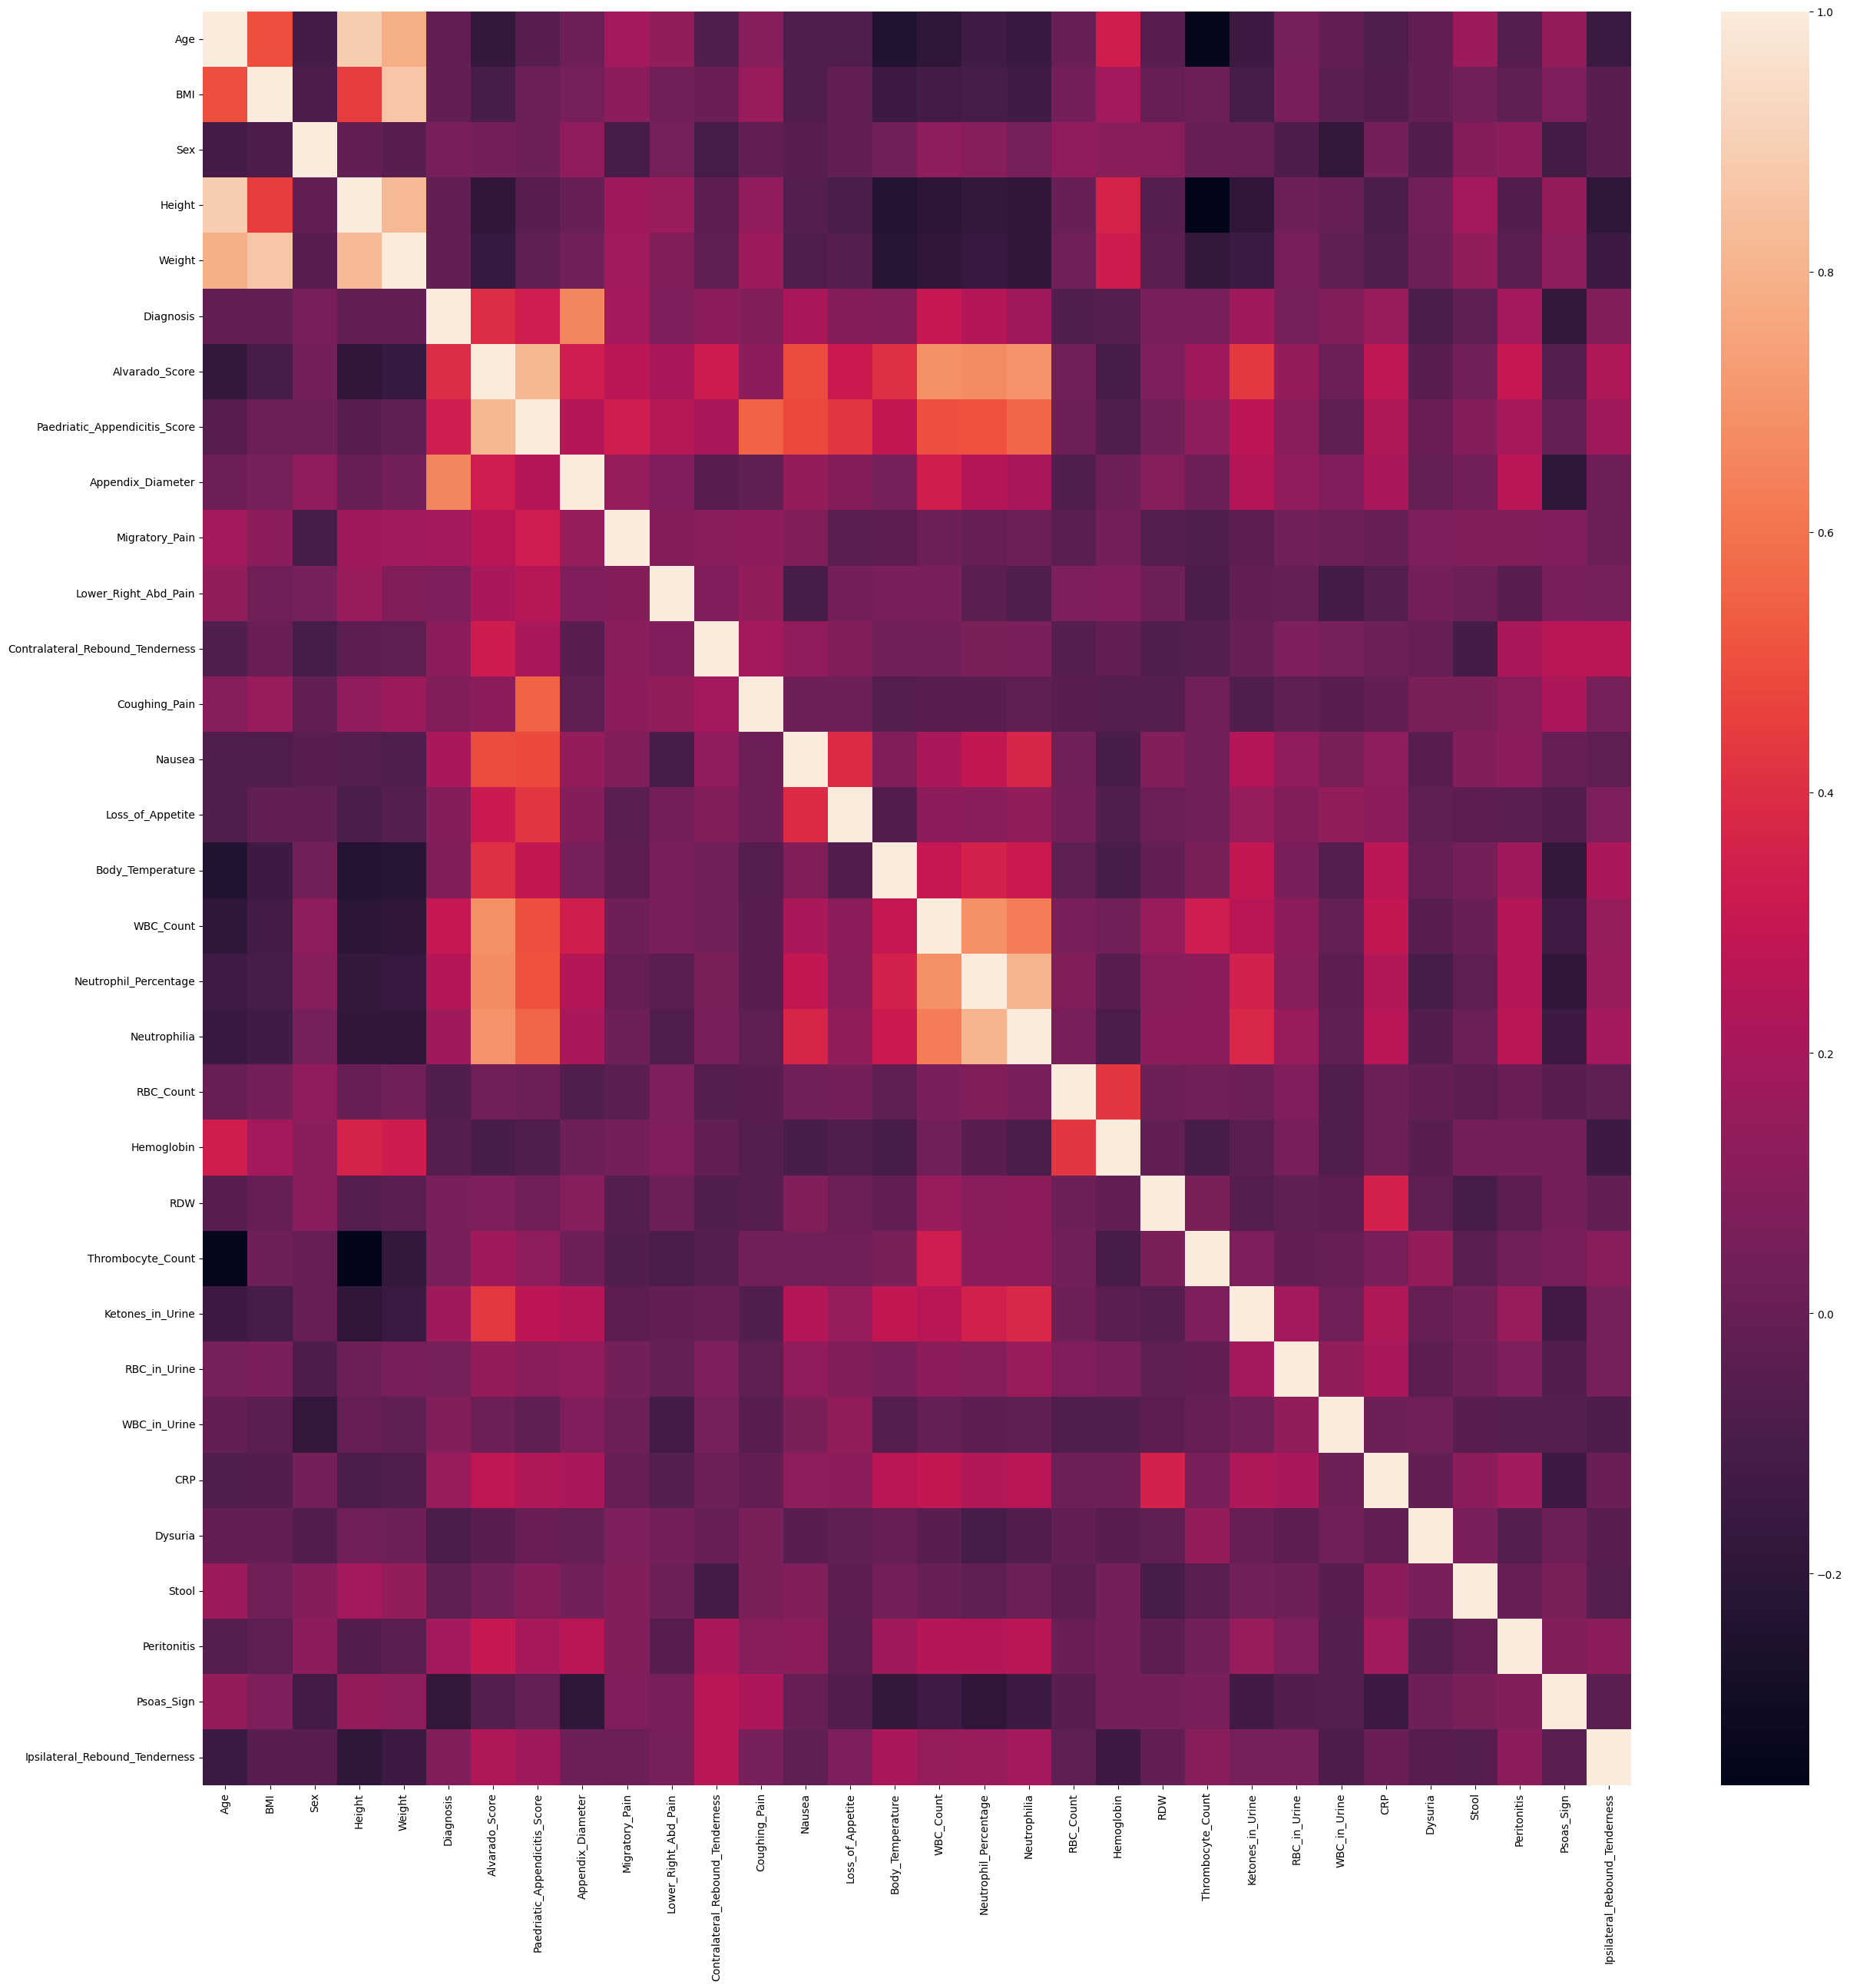

In [66]:
plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())

In [67]:
df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)

In [68]:
df2["Diagnosis"].value_counts()

1    157
0     81
Name: Diagnosis, dtype: int64

In [69]:
# dsafsf

In [70]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(238, 32)

# APPLYING BORUTA ALGORITHM FOR FEATURE SELECTION

Iteration: 	1 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	2 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	3 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	4 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	5 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	6 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	7 / 10
Confirmed: 	0
Tentative: 	32
Rejected: 	0
Iteration: 	8 / 10
Confirmed: 	0
Tentative: 	4
Rejected: 	28
Iteration: 	9 / 10
Confirmed: 	2
Tentative: 	2
Rejected: 	28


BorutaPy finished running.

Iteration: 	10 / 10
Confirmed: 	2
Tentative: 	2
Rejected: 	28

------Support and Ranking for each feature------
Doesn't pass the test:  Age  - Ranking:  15
Doesn't pass the test:  BMI  - Ranking:  7
Doesn't pass the test:  Sex  - Ranking:  25
Doesn't pass the test:  Height  - Ranking:  11
Doesn't pass the test:  Weight  - Ranking:  6
Passes the test:  Alvarado_Score  - Ranking:  1
Doesn't pass the test:  Paedriatic_Ap

Index(['Alvarado_Score', 'Appendix_Diameter', 'Paedriatic_Appendicitis_Score',
       'Coughing_Pain', 'WBC_Count', 'Thrombocyte_Count', 'CRP', 'Weight',
       'BMI', 'Neutrophil_Percentage', 'RDW', 'RBC_Count', 'Height', 'Stool',
       'Body_Temperature', 'Hemoglobin', 'Age',
       'Contralateral_Rebound_Tenderness', 'Peritonitis', 'Free_Fluids',
       'Ketones_in_Urine'],
      dtype='object')

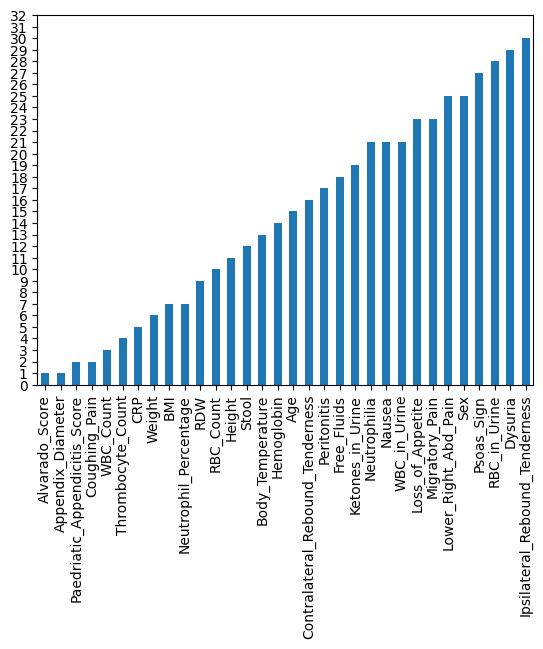

In [72]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(x,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(x), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", x.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              x.columns[i], " - Ranking: ", feat_selector.ranking_[i])
        
        
        
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)



sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly



brt20 = sel_col[sel_col.values<21]
brt20.index

In [73]:
cols = brt20.index

In [74]:
col =list(cols)
col.append("Diagnosis")
df = df.loc[:,col]

In [75]:
col

['Alvarado_Score',
 'Appendix_Diameter',
 'Paedriatic_Appendicitis_Score',
 'Coughing_Pain',
 'WBC_Count',
 'Thrombocyte_Count',
 'CRP',
 'Weight',
 'BMI',
 'Neutrophil_Percentage',
 'RDW',
 'RBC_Count',
 'Height',
 'Stool',
 'Body_Temperature',
 'Hemoglobin',
 'Age',
 'Contralateral_Rebound_Tenderness',
 'Peritonitis',
 'Free_Fluids',
 'Ketones_in_Urine',
 'Diagnosis']

In [76]:
df["Diagnosis"].value_counts()

1    463
0    317
Name: Diagnosis, dtype: int64

In [77]:
# df4 = df.dropna()
# aaaaaaaaaa

In [78]:
# df4.shape
df2["Free_Fluids"].value_counts()

0    142
1     96
Name: Free_Fluids, dtype: int64

C:\Users\shadj\AppData\Local\Temp\ipykernel_25880\3217089177.py:18: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df.corr()
C:\Users\shadj\AppData\Local\Temp\ipykernel_25880\3217089177.py:333: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  df2.corr()["Diagnosis"]
C:\Users\shadj\AppData\Local\Temp\ipykernel_25880\3217089177.py:340: FutureWarning: The default value of numeric_only in DataFrame.corr is deprecated. In a future version, it will default to False. Select only valid columns or specify the value of numeric_only to silence this warning.
  sns.heatmap(df2.corr())


<class 'pandas.core.frame.DataFrame'>
Int64Index: 297 entries, 0 to 781
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Alvarado_Score                    297 non-null    float64
 1   Appendix_Diameter                 297 non-null    float64
 2   Paedriatic_Appendicitis_Score     297 non-null    float64
 3   Coughing_Pain                     297 non-null    int32  
 4   WBC_Count                         297 non-null    float64
 5   Thrombocyte_Count                 297 non-null    float64
 6   CRP                               297 non-null    float64
 7   Weight                            297 non-null    float64
 8   BMI                               297 non-null    float64
 9   Neutrophil_Percentage             297 non-null    float64
 10  RDW                               297 non-null    float64
 11  RBC_Count                         297 non-null    float64
 12  Height  

1    216
0     81
Name: Diagnosis, dtype: int64

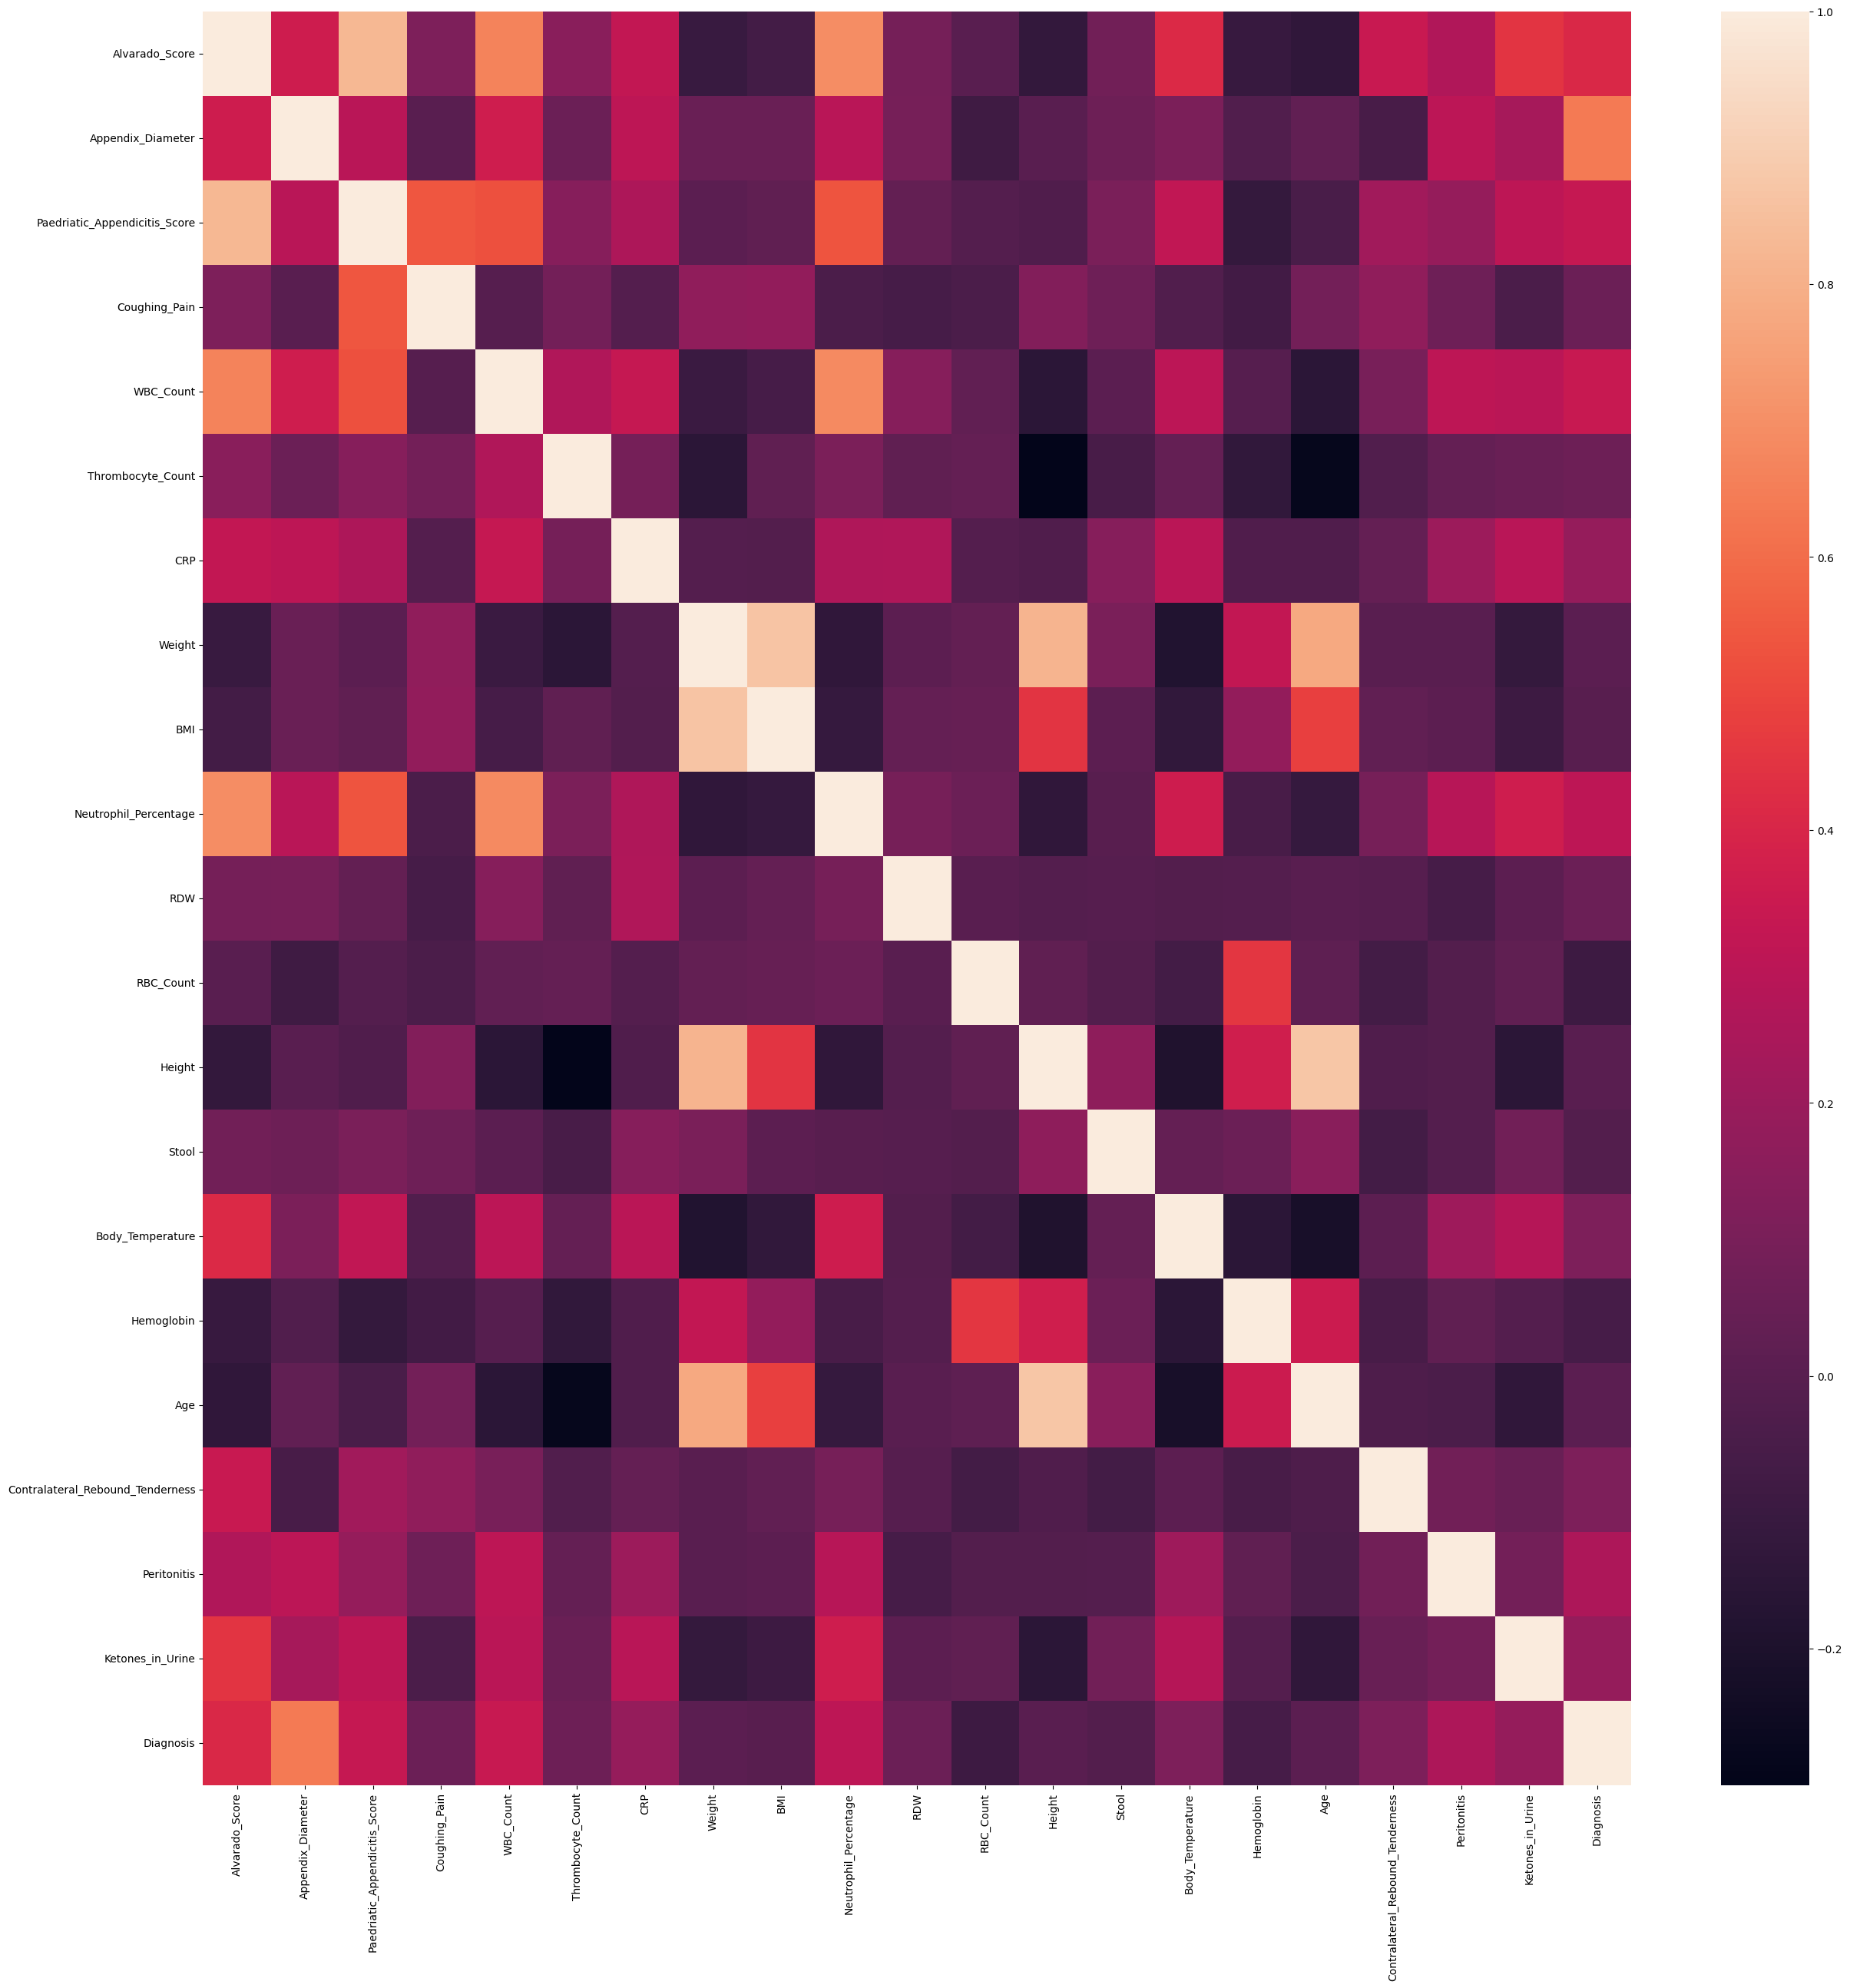

In [94]:
# preprocessing:


# removing the rows whose diagnosis column is nan
# df = df[df['Diagnosis'].notna()]
# df['Diagnosis'].value_counts(dropna = False)


# In[8]:


#converting the diagnosis value to int type
# df["Diagnosis"] = (df['Diagnosis']=='appendicitis').astype(int)



# correlation of different columns with each other
df.corr()


# #  correlation of our output column with other columns
# df.corr()['Diagnosis']


# df


# # In[14]:


# #This is the list of other target or output columns
# target_cols = ["Diagnosis_Presumptive","Management","Severity","Length_of_Stay"]


# # In[15]:


# # REmoving other target columns since they are not necessary
# df.drop(target_cols,axis=1,inplace =True)


# # In[16]:


# #information of the remaining dataframe
# df.info()


# # In[17]:


# #removing the "Segmented_Neutrophils" Column, Since it had very few values
# df.drop("Segmented_Neutrophils",axis=1,inplace=True)


# # In[18]:


# df.info()


# <h2>Selecting only those rows which have no nan values : </h2>

# In[19]:


df2 = df.dropna().copy()


# In[20]:


df2


# In[21]:


df2.columns


# In[22]:


# df2["WBC_in_Urine"].value_counts()


# In[23]:


# df2["Sex"].value_counts()


# In[24]:


df2["Diagnosis"].value_counts()


# In[25]:


# df.info()


# In[26]:


# df2["Sex"].value_counts()


# In[27]:


# df2["Sex"] = (df["Sex"]=="male").astype(int)


# In[28]:


# df2['Migratory_Pain']= (df2['Migratory_Pain']=='yes').astype(int)


# In[29]:


# df.info()


# In[30]:


# df2["Lower_Right_Abd_Pain"].value_counts()


# In[31]:


# df2["Lower_Right_Abd_Pain"] =(df["Lower_Right_Abd_Pain"]=="yes").astype(int)
# df2["Lower_Right_Abd_Pain"].value_counts()


# In[32]:


# df2["Contralateral_Rebound_Tenderness"].value_counts()


# In[33]:


df2["Contralateral_Rebound_Tenderness"] = (df["Contralateral_Rebound_Tenderness"]=='yes').astype(int)
df2['Contralateral_Rebound_Tenderness'].value_counts()


# In[34]:


# df2["Coughing_Pain"].value_counts(dropna = False)


# In[35]:


df2["Coughing_Pain"] = (df2["Coughing_Pain"] =="yes").astype(int)
df2["Coughing_Pain"].value_counts()


# In[36]:


# df2["Nausea"].value_counts(dropna = False)


# In[37]:


# df2["Nausea"] = (df["Nausea"]=='yes').astype(int)
# df2["Nausea"].value_counts()


# In[38]:


# df2["Loss_of_Appetite"].value_counts(dropna= False)


# In[39]:


# df2["Loss_of_Appetite"] = (df2["Loss_of_Appetite"]=='yes').astype(int)
# df2["Loss_of_Appetite"].value_counts()


# In[40]:


# df2["Neutrophilia"].value_counts(dropna = False)


# In[41]:


# df2["Neutrophilia"] = (df["Neutrophilia"]== 'yes').astype(int)
# df2["Neutrophilia"].value_counts()


# In[42]:


# df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[43]:


from sklearn.preprocessing import OrdinalEncoder
enc = OrdinalEncoder(categories=[['no','+','++','+++']])
enc.fit([['no'], ['+'], ['++'],['+++']])                                 
df2["Ketones_in_Urine"] = enc.fit_transform(df2[["Ketones_in_Urine"]])
df2["Ketones_in_Urine"].value_counts(dropna = False)


# In[44]:


df2.info()


# In[45]:


# df2["RBC_in_Urine"].value_counts(dropna = False)


# In[46]:


# enc = OrdinalEncoder(categories=[['no','+','++','+++']])
# enc.fit([['no'], ['+'], ['++'],['+++']])                                 
# df2["RBC_in_Urine"] = enc.fit_transform(df2[["RBC_in_Urine"]])
# df2["RBC_in_Urine"].value_counts(dropna = False)


# In[47]:


# df2["WBC_in_Urine"].value_counts(dropna= False)


# In[48]:


# enc = OrdinalEncoder(categories=[['no','+','++','+++']])
# enc.fit([['no'], ['+'], ['++'],['+++']])                                 
# df2["WBC_in_Urine"] = enc.fit_transform(df2[["WBC_in_Urine"]])
# df2["WBC_in_Urine"].value_counts(dropna = False)


# In[49]:


# df2["Dysuria"].value_counts(dropna= False)


# In[50]:


# df2["Dysuria"] = (df2["Dysuria"]=='yes').astype(int)
# df2["Dysuria"].value_counts()


# In[51]:


# df2["Stool"].value_counts()
#will do one hot encoding here


# In[52]:


enc = OrdinalEncoder(categories=[['constipation','normal','diarrhea']])
enc.fit([['constipation'], ['normal'], ['diarrhea']])                                 
df2["Stool"] = enc.fit_transform(df2[["Stool"]])
df2["Stool"].value_counts(dropna = False)


# In[53]:


df2["Peritonitis"] = (df2["Peritonitis"]!='no').astype(int)

# In[58]:


# df2["Diagnosis"].corr(df2["Peritonitis_binary"])


# In[59]:


# df2["Psoas_Sign"].value_counts()


# In[60]:


# df2["Psoas_Sign"]= (df2["Psoas_Sign"]=='yes').astype(int)


# In[61]:


# df2["Ipsilateral_Rebound_Tenderness"].value_counts()


# In[62]:


# df2["Ipsilateral_Rebound_Tenderness"] = (df2["Ipsilateral_Rebound_Tenderness"]=='yes').astype(int)


# In[63]:


df2.info()


# In[64]:


df2.corr()["Diagnosis"]


# In[65]:


plt.figure(figsize=(30,30))
sns.heatmap(df2.corr())


# In[66]:


df2["Free_Fluids"] =(df["Free_Fluids"]=='yes').astype(int)


# In[67]:


df2["Diagnosis"].value_counts()


In [95]:
df2.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 297 entries, 0 to 781
Data columns (total 22 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Alvarado_Score                    297 non-null    float64
 1   Appendix_Diameter                 297 non-null    float64
 2   Paedriatic_Appendicitis_Score     297 non-null    float64
 3   Coughing_Pain                     297 non-null    int32  
 4   WBC_Count                         297 non-null    float64
 5   Thrombocyte_Count                 297 non-null    float64
 6   CRP                               297 non-null    float64
 7   Weight                            297 non-null    float64
 8   BMI                               297 non-null    float64
 9   Neutrophil_Percentage             297 non-null    float64
 10  RDW                               297 non-null    float64
 11  RBC_Count                         297 non-null    float64
 12  Height  

In [96]:
y = df2.loc[:,"Diagnosis"]
y.value_counts()
x = df2.loc[:,df2.columns!='Diagnosis']
x.shape

(297, 21)

In [97]:
y.value_counts()

1    216
0     81
Name: Diagnosis, dtype: int64

In [98]:
x.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 297 entries, 0 to 781
Data columns (total 21 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Alvarado_Score                    297 non-null    float64
 1   Appendix_Diameter                 297 non-null    float64
 2   Paedriatic_Appendicitis_Score     297 non-null    float64
 3   Coughing_Pain                     297 non-null    int32  
 4   WBC_Count                         297 non-null    float64
 5   Thrombocyte_Count                 297 non-null    float64
 6   CRP                               297 non-null    float64
 7   Weight                            297 non-null    float64
 8   BMI                               297 non-null    float64
 9   Neutrophil_Percentage             297 non-null    float64
 10  RDW                               297 non-null    float64
 11  RBC_Count                         297 non-null    float64
 12  Height  

In [99]:
from sklearn.model_selection import train_test_split

In [100]:
x_train, x_test , y_train, y_test = train_test_split(x,y,test_size=0.2,random_state=42)

In [101]:
x_train.shape

(237, 21)

In [102]:
# y_train.value_counts()

In [103]:
# col
x_train.columns

Index(['Alvarado_Score', 'Appendix_Diameter', 'Paedriatic_Appendicitis_Score',
       'Coughing_Pain', 'WBC_Count', 'Thrombocyte_Count', 'CRP', 'Weight',
       'BMI', 'Neutrophil_Percentage', 'RDW', 'RBC_Count', 'Height', 'Stool',
       'Body_Temperature', 'Hemoglobin', 'Age',
       'Contralateral_Rebound_Tenderness', 'Peritonitis', 'Free_Fluids',
       'Ketones_in_Urine'],
      dtype='object')

In [104]:
y_test.value_counts()
y_train.value_counts()

1    175
0     62
Name: Diagnosis, dtype: int64

In [105]:
from sklearn.neighbors import KNeighborsClassifier
model = KNeighborsClassifier(n_neighbors=5)
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.45      0.26      0.33        19
           1       0.71      0.85      0.78        41

    accuracy                           0.67        60
   macro avg       0.58      0.56      0.56        60
weighted avg       0.63      0.67      0.64        60



In [106]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.00 ± 0.00
SCORE_TIME - Mean: 0.05 ± 0.01
TEST_ACCURACY - Mean: 0.72 ± 0.08
TEST_F1 - Mean: 0.81 ± 0.06
TEST_ROC_AUC - Mean: 0.65 ± 0.07
TEST_AVERAGE_PRECISION - Mean: 0.79 ± 0.06
TEST_PRECISION - Mean: 0.77 ± 0.07
TEST_RECALL - Mean: 0.86 ± 0.06


In [107]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.2f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.7941
Fold 2: AUPR = 0.8141
Fold 3: AUPR = 0.7522
Fold 4: AUPR = 0.9031
Fold 5: AUPR = 0.8336

Average AUPR: 0.82 +- 0.05


In [108]:
from sklearn.naive_bayes import GaussianNB
NB = GaussianNB()
NB = NB.fit(x_train,y_train)
y_pred = NB.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.57      0.84      0.68        19
           1       0.91      0.71      0.79        41

    accuracy                           0.75        60
   macro avg       0.74      0.77      0.74        60
weighted avg       0.80      0.75      0.76        60



In [109]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(NB,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.02 ± 0.01
TEST_ACCURACY - Mean: 0.73 ± 0.06
TEST_F1 - Mean: 0.79 ± 0.06
TEST_ROC_AUC - Mean: 0.87 ± 0.04
TEST_AVERAGE_PRECISION - Mean: 0.94 ± 0.02
TEST_PRECISION - Mean: 0.90 ± 0.06
TEST_RECALL - Mean: 0.72 ± 0.09


In [110]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.2f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.7941
Fold 2: AUPR = 0.8141
Fold 3: AUPR = 0.7522
Fold 4: AUPR = 0.9031
Fold 5: AUPR = 0.8336

Average AUPR: 0.82 +- 0.05


In [111]:
from sklearn.svm import SVC
model = SVC()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        19
           1       0.68      1.00      0.81        41

    accuracy                           0.68        60
   macro avg       0.34      0.50      0.41        60
weighted avg       0.47      0.68      0.55        60



C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
C:\Users\shadj\Python\Python310\lib\site-packages\sklearn\metrics\_classification.py:1471: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


In [112]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.00
TEST_ACCURACY - Mean: 0.73 ± 0.05
TEST_F1 - Mean: 0.84 ± 0.03
TEST_ROC_AUC - Mean: 0.79 ± 0.05
TEST_AVERAGE_PRECISION - Mean: 0.91 ± 0.04
TEST_PRECISION - Mean: 0.73 ± 0.05
TEST_RECALL - Mean: 1.00 ± 0.00


In [113]:
# This will not work here

# from sklearn.metrics import precision_recall_curve,auc
# def calc_aupr():
#     # Initialize list to store AUPR values for each fold
#     aupr_list = []
 
#     X = x
#     # Perform 5-fold cross-validation
#     for train_index, test_index in kf.split(X):
#         X_train, X_test = X.iloc[train_index], X.iloc[test_index]
#         y_train, y_test = y.iloc[train_index], y.iloc[test_index]

#         # Train the model
#         model.fit(X_train, y_train)

#         # Predict probabilities on the validation set
#         y_proba = model.predict_proba(X_test)

#         # Compute precision and recall
#         precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

#         # Compute AUPR for the current fold
#         aupr = auc(recall, precision)

#         # Append AUPR to the list
#         aupr_list.append(aupr)

#     # Print AUPR values for each fold
#     for fold, aupr in enumerate(aupr_list, start=1):
#         print(f"Fold {fold}: AUPR = {aupr:.4f}")

#     # Calculate and print average AUPR over all folds
#     avg_aupr = np.mean(aupr_list)
#     std_aupr = np.std(aupr_list)
#     print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

# calc_aupr()

In [114]:
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      1.00      0.93        19
           1       1.00      0.93      0.96        41

    accuracy                           0.95        60
   macro avg       0.93      0.96      0.94        60
weighted avg       0.96      0.95      0.95        60



In [115]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

FIT_TIME - Mean: 0.01 ± 0.00
SCORE_TIME - Mean: 0.03 ± 0.00
TEST_ACCURACY - Mean: 0.93 ± 0.03
TEST_F1 - Mean: 0.95 ± 0.02
TEST_ROC_AUC - Mean: 0.89 ± 0.05
TEST_AVERAGE_PRECISION - Mean: 0.93 ± 0.04
TEST_PRECISION - Mean: 0.93 ± 0.04
TEST_RECALL - Mean: 0.97 ± 0.03


In [116]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9884
Fold 2: AUPR = 0.9286
Fold 3: AUPR = 0.9659
Fold 4: AUPR = 0.9729
Fold 5: AUPR = 0.9826

Average AUPR: 0.9677 +- 0.02


In [117]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier()
model = model.fit(x_train,y_train)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.89      0.85      0.87        20
           1       0.93      0.95      0.94        40

    accuracy                           0.92        60
   macro avg       0.91      0.90      0.91        60
weighted avg       0.92      0.92      0.92        60



In [118]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate
# x_train = pd.DataFrame(x_train)
# x_test = pd.DataFrame(x_test)
# y_train = pd.DataFrame(y_train)
# y_test = pd.DataFrame(y_test)
# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


FIT_TIME - Mean: 0.43 ± 0.02
SCORE_TIME - Mean: 0.05 ± 0.01
TEST_ACCURACY - Mean: 0.95 ± 0.02
TEST_F1 - Mean: 0.97 ± 0.01
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 1.00 ± 0.00


In [119]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

Fold 1: AUPR = 0.9917
Fold 2: AUPR = 0.9977
Fold 3: AUPR = 0.9982
Fold 4: AUPR = 0.9963
Fold 5: AUPR = 0.9992

Average AUPR: 0.9966 +- 0.00


In [120]:
from xgboost import XGBClassifier
# from catboost import CatBoostClassifier
model = XGBClassifier(iterations=1500,learning_rate=0.1,depth=6,loss_function='Logloss')
model.fit(x_train,y_train,verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.86      0.95      0.90        19
           1       0.97      0.93      0.95        41

    accuracy                           0.93        60
   macro avg       0.92      0.94      0.93        60
weighted avg       0.94      0.93      0.93        60



C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:12] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)


In [121]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= x
# y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:13] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.



FIT_TIME - Mean: 0.15 ± 0.01
SCORE_TIME - Mean: 0.05 ± 0.00
TEST_ACCURACY - Mean: 0.95 ± 0.02
TEST_F1 - Mean: 0.96 ± 0.01
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 1.00 ± 0.00
TEST_PRECISION - Mean: 0.98 ± 0.01
TEST_RECALL - Mean: 0.94 ± 0.02


C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)


In [122]:
X.columns

Index(['Alvarado_Score', 'Appendix_Diameter', 'Paedriatic_Appendicitis_Score',
       'Coughing_Pain', 'WBC_Count', 'Thrombocyte_Count', 'CRP', 'Weight',
       'BMI', 'Neutrophil_Percentage', 'RDW', 'RBC_Count', 'Height', 'Stool',
       'Body_Temperature', 'Hemoglobin', 'Age',
       'Contralateral_Rebound_Tenderness', 'Peritonitis', 'Free_Fluids',
       'Ketones_in_Urine'],
      dtype='object')

In [123]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:14] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.



Fold 1: AUPR = 0.9885
Fold 2: AUPR = 0.9967
Fold 3: AUPR = 0.9994
Fold 4: AUPR = 0.9954
Fold 5: AUPR = 0.9976

Average AUPR: 0.9955 +- 0.00


C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)


In [124]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,x,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:15] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.



FIT_TIME - Mean: 0.15 ± 0.01
SCORE_TIME - Mean: 0.05 ± 0.00
TEST_ACCURACY - Mean: 0.95 ± 0.02
TEST_F1 - Mean: 0.96 ± 0.01
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 1.00 ± 0.00
TEST_PRECISION - Mean: 0.98 ± 0.01
TEST_RECALL - Mean: 0.94 ± 0.02


C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)


In [125]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])

X =x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")


C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)
C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:16] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.



FIT_TIME - Mean: 0.13 ± 0.01
SCORE_TIME - Mean: 0.05 ± 0.00
TEST_ACCURACY - Mean: 0.95 ± 0.02
TEST_F1 - Mean: 0.96 ± 0.01
TEST_ROC_AUC - Mean: 0.99 ± 0.01
TEST_AVERAGE_PRECISION - Mean: 1.00 ± 0.00
TEST_PRECISION - Mean: 0.98 ± 0.01
TEST_RECALL - Mean: 0.94 ± 0.02


C:\Users\shadj\Python\Python310\lib\site-packages\xgboost\core.py:160: UserWarning: [12:29:17] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0b3782d1791676daf-1\xgboost\xgboost-ci-windows\src\learner.cc:742: 
Parameters: { "depth", "iterations", "loss_function" } are not used.

  warnings.warn(smsg, UserWarning)


In [126]:
from catboost import CatBoostClassifier
model =  CatBoostClassifier(iterations=1500, learning_rate=0.01, depth=5, loss_function='Logloss')
model.fit(x_train,y_train, eval_set= (x_test,y_test), verbose=False)
y_pred = model.predict(x_test)
print(classification_report(y_pred,y_test))

              precision    recall  f1-score   support

           0       0.95      0.86      0.90        21
           1       0.93      0.97      0.95        39

    accuracy                           0.93        60
   macro avg       0.94      0.92      0.93        60
weighted avg       0.93      0.93      0.93        60



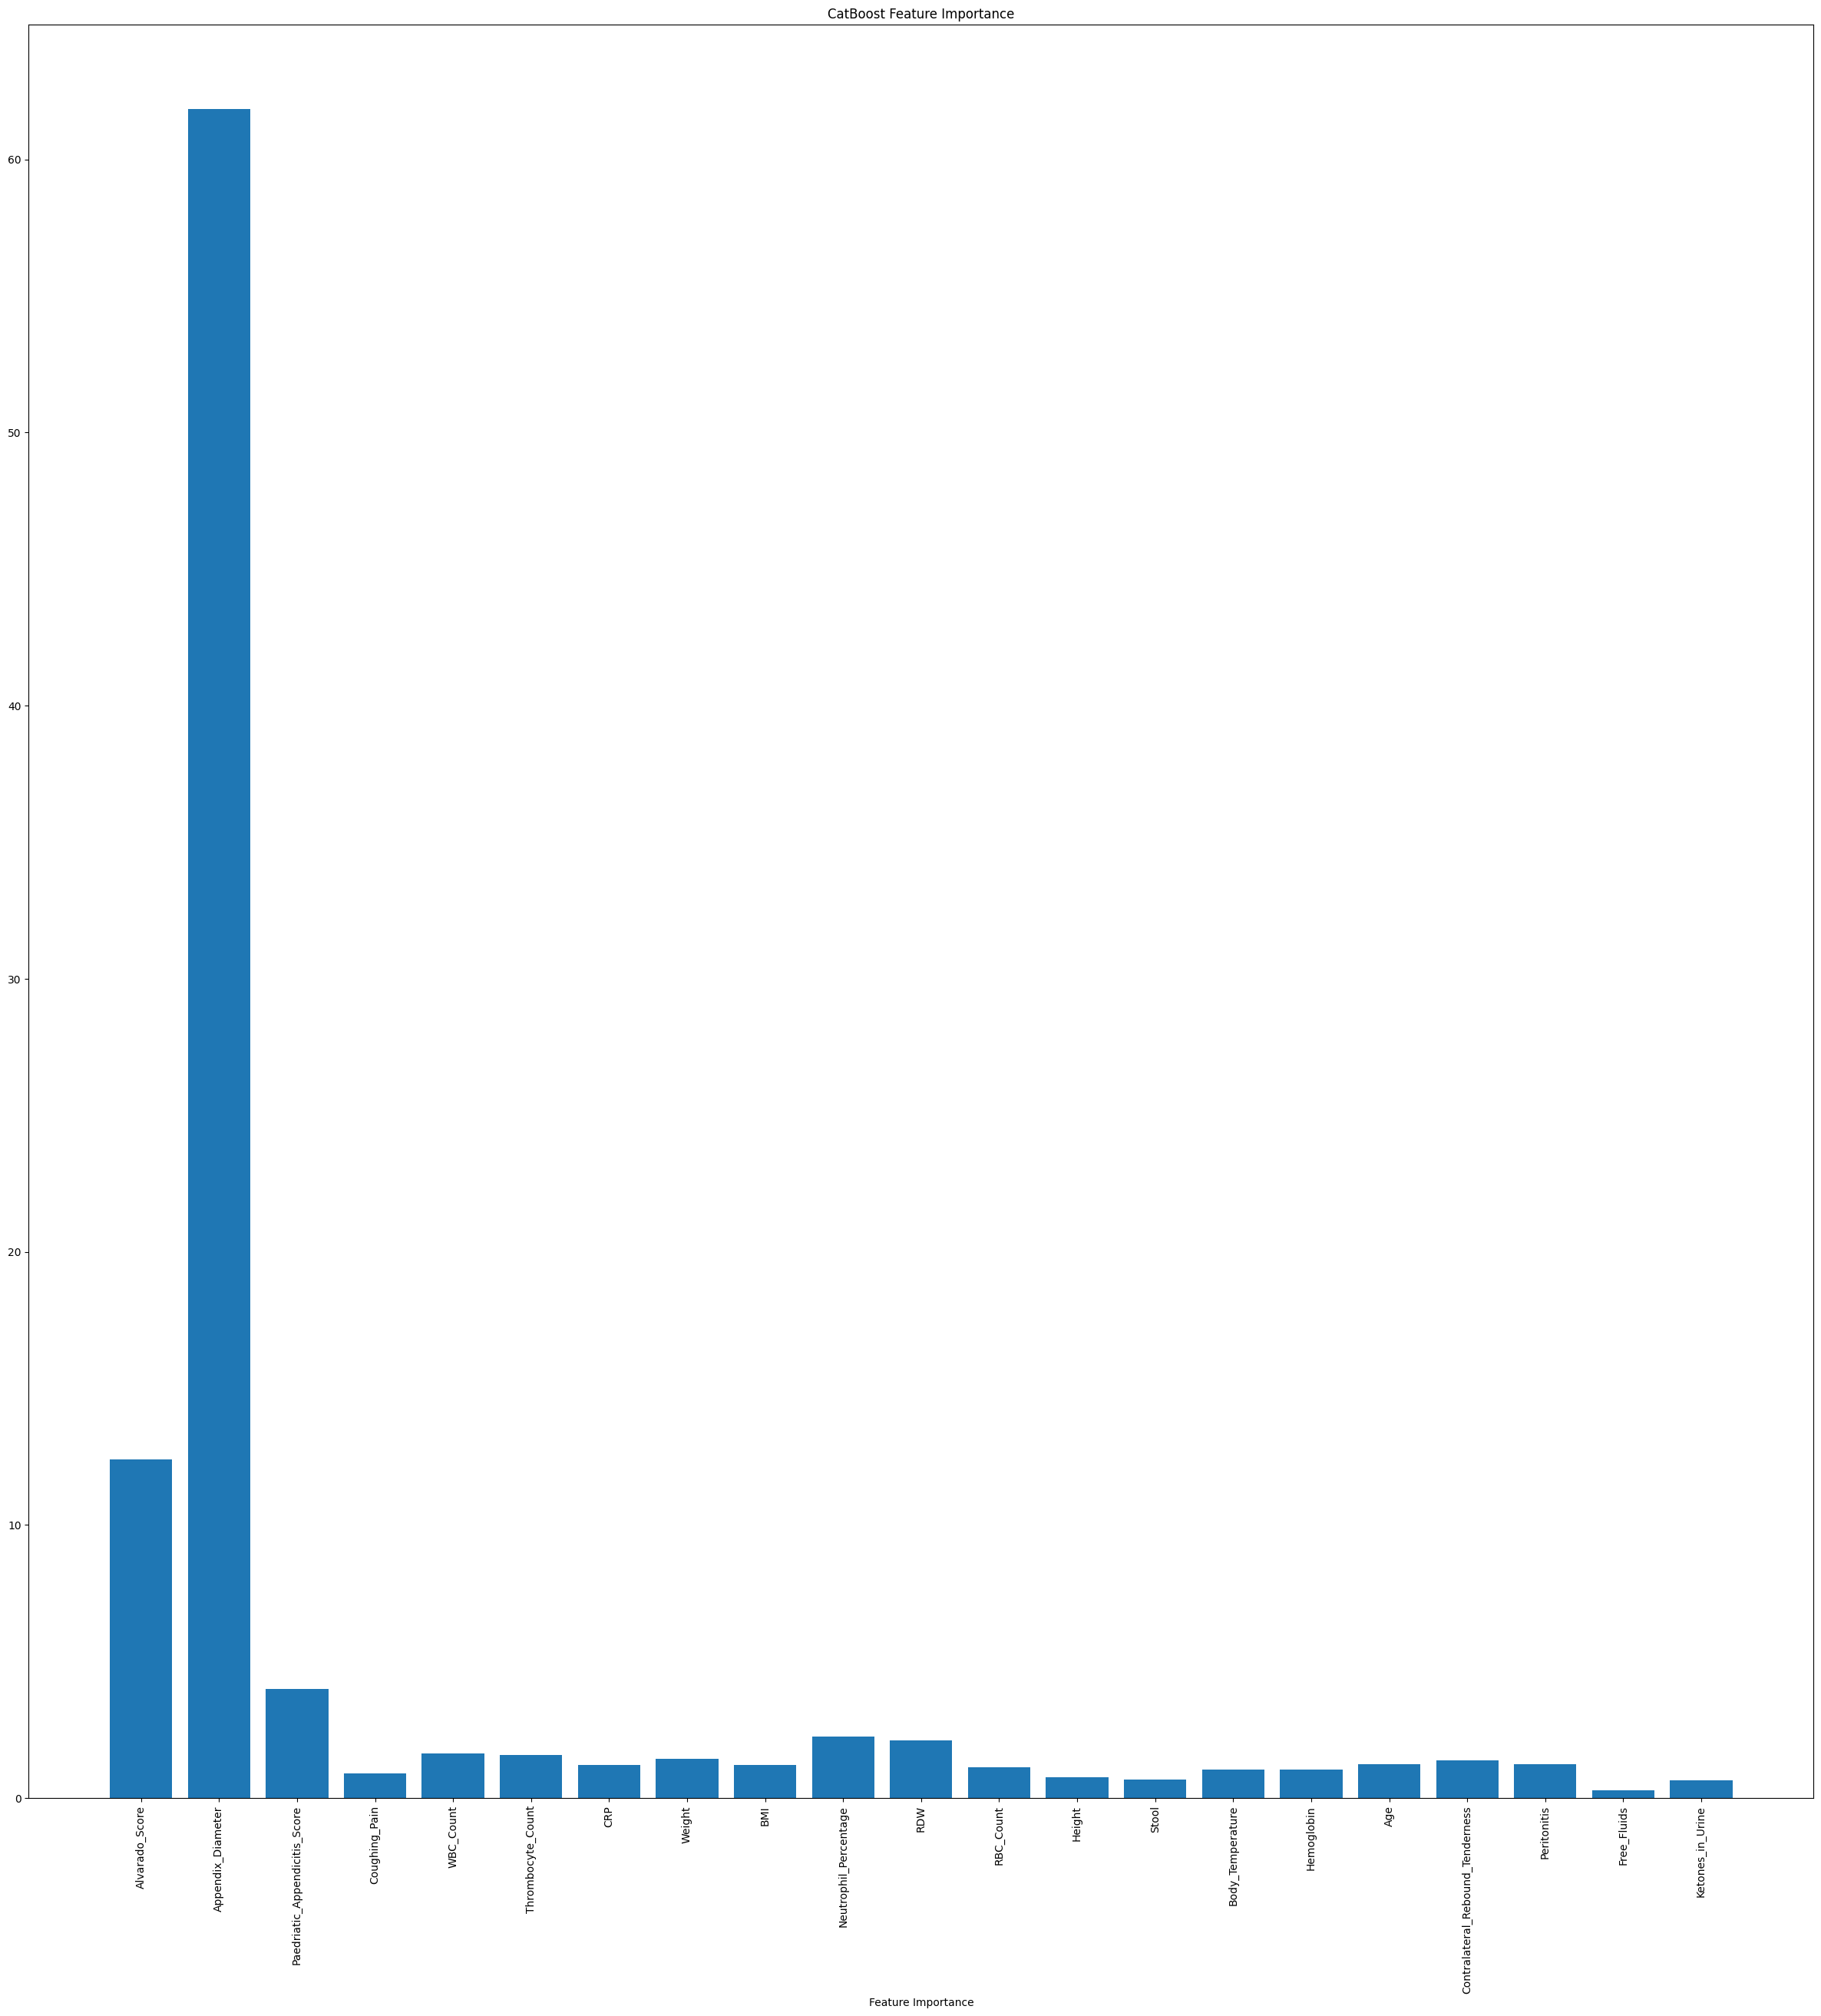

In [127]:
import matplotlib.pyplot as plt    
feature_importance = model.get_feature_importance()
feature_names = X.columns 
plt.figure(figsize=(30,30))
plt.bar(feature_names, feature_importance) 
plt.xlabel("Feature Importance") 
plt.title("CatBoost Feature Importance")
plt.xticks(rotation=90)
plt.show()

In [128]:
from sklearn.model_selection import KFold, cross_val_score,cross_validate

# X= pd.concat([x_train,x_test])
# y= pd.concat([y_train,y_test])
X = x
scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)

for value in scores:
    v = str(value)
    mean_score = scores[v].mean()
    std_score = scores[v].std()
    print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

0:	learn: 0.6802405	total: 5.29ms	remaining: 7.93s
1:	learn: 0.6682511	total: 11.3ms	remaining: 8.46s
2:	learn: 0.6501831	total: 17.2ms	remaining: 8.57s
3:	learn: 0.6390808	total: 22.5ms	remaining: 8.41s
4:	learn: 0.6232145	total: 28.2ms	remaining: 8.43s
5:	learn: 0.6090347	total: 32.9ms	remaining: 8.2s
6:	learn: 0.5936300	total: 38.5ms	remaining: 8.22s
7:	learn: 0.5824856	total: 45.5ms	remaining: 8.48s
8:	learn: 0.5737572	total: 51.3ms	remaining: 8.51s
9:	learn: 0.5622349	total: 57.1ms	remaining: 8.51s
10:	learn: 0.5507331	total: 63.2ms	remaining: 8.56s
11:	learn: 0.5429626	total: 68.8ms	remaining: 8.54s
12:	learn: 0.5294894	total: 74.1ms	remaining: 8.48s
13:	learn: 0.5221668	total: 79.9ms	remaining: 8.48s
14:	learn: 0.5125506	total: 88.5ms	remaining: 8.76s
15:	learn: 0.5027626	total: 94.3ms	remaining: 8.75s
16:	learn: 0.4931289	total: 101ms	remaining: 8.84s
17:	learn: 0.4801358	total: 108ms	remaining: 8.89s
18:	learn: 0.4719788	total: 114ms	remaining: 8.89s
19:	learn: 0.4616574	total

161:	learn: 0.0906269	total: 995ms	remaining: 8.21s
162:	learn: 0.0898561	total: 1s	remaining: 8.21s
163:	learn: 0.0894188	total: 1.01s	remaining: 8.2s
164:	learn: 0.0891080	total: 1.01s	remaining: 8.21s
165:	learn: 0.0884701	total: 1.02s	remaining: 8.2s
166:	learn: 0.0880927	total: 1.03s	remaining: 8.2s
167:	learn: 0.0877030	total: 1.03s	remaining: 8.2s
168:	learn: 0.0871377	total: 1.04s	remaining: 8.21s
169:	learn: 0.0868297	total: 1.05s	remaining: 8.21s
170:	learn: 0.0857235	total: 1.06s	remaining: 8.21s
171:	learn: 0.0851772	total: 1.06s	remaining: 8.21s
172:	learn: 0.0845465	total: 1.07s	remaining: 8.2s
173:	learn: 0.0840817	total: 1.07s	remaining: 8.19s
174:	learn: 0.0836504	total: 1.08s	remaining: 8.18s
175:	learn: 0.0833206	total: 1.09s	remaining: 8.17s
176:	learn: 0.0830252	total: 1.09s	remaining: 8.17s
177:	learn: 0.0826524	total: 1.1s	remaining: 8.16s
178:	learn: 0.0821636	total: 1.11s	remaining: 8.16s
179:	learn: 0.0814778	total: 1.11s	remaining: 8.15s
180:	learn: 0.0811335

348:	learn: 0.0397742	total: 2.17s	remaining: 7.17s
349:	learn: 0.0394927	total: 2.18s	remaining: 7.15s
350:	learn: 0.0393347	total: 2.18s	remaining: 7.15s
351:	learn: 0.0392558	total: 2.19s	remaining: 7.14s
352:	learn: 0.0390445	total: 2.19s	remaining: 7.13s
353:	learn: 0.0389899	total: 2.2s	remaining: 7.12s
354:	learn: 0.0388370	total: 2.2s	remaining: 7.11s
355:	learn: 0.0387189	total: 2.21s	remaining: 7.11s
356:	learn: 0.0386035	total: 2.22s	remaining: 7.1s
357:	learn: 0.0384871	total: 2.22s	remaining: 7.09s
358:	learn: 0.0383803	total: 2.23s	remaining: 7.09s
359:	learn: 0.0382311	total: 2.23s	remaining: 7.08s
360:	learn: 0.0381180	total: 2.24s	remaining: 7.07s
361:	learn: 0.0381036	total: 2.25s	remaining: 7.06s
362:	learn: 0.0379892	total: 2.25s	remaining: 7.06s
363:	learn: 0.0379142	total: 2.26s	remaining: 7.05s
364:	learn: 0.0376496	total: 2.27s	remaining: 7.05s
365:	learn: 0.0375973	total: 2.27s	remaining: 7.04s
366:	learn: 0.0375147	total: 2.28s	remaining: 7.04s
367:	learn: 0.0

523:	learn: 0.0234764	total: 3.18s	remaining: 5.92s
524:	learn: 0.0234241	total: 3.19s	remaining: 5.92s
525:	learn: 0.0233407	total: 3.19s	remaining: 5.91s
526:	learn: 0.0233253	total: 3.2s	remaining: 5.91s
527:	learn: 0.0233084	total: 3.21s	remaining: 5.91s
528:	learn: 0.0232299	total: 3.21s	remaining: 5.9s
529:	learn: 0.0231063	total: 3.22s	remaining: 5.89s
530:	learn: 0.0230275	total: 3.23s	remaining: 5.89s
531:	learn: 0.0230104	total: 3.23s	remaining: 5.88s
532:	learn: 0.0229887	total: 3.24s	remaining: 5.88s
533:	learn: 0.0229335	total: 3.24s	remaining: 5.87s
534:	learn: 0.0228737	total: 3.25s	remaining: 5.86s
535:	learn: 0.0227934	total: 3.26s	remaining: 5.86s
536:	learn: 0.0227013	total: 3.26s	remaining: 5.85s
537:	learn: 0.0226799	total: 3.27s	remaining: 5.84s
538:	learn: 0.0226573	total: 3.27s	remaining: 5.84s
539:	learn: 0.0226472	total: 3.28s	remaining: 5.83s
540:	learn: 0.0225830	total: 3.29s	remaining: 5.83s
541:	learn: 0.0225522	total: 3.29s	remaining: 5.82s
542:	learn: 0.

682:	learn: 0.0163068	total: 4.19s	remaining: 5.01s
683:	learn: 0.0163003	total: 4.19s	remaining: 5s
684:	learn: 0.0162615	total: 4.2s	remaining: 5s
685:	learn: 0.0161832	total: 4.21s	remaining: 4.99s
686:	learn: 0.0161768	total: 4.21s	remaining: 4.98s
687:	learn: 0.0161137	total: 4.21s	remaining: 4.97s
688:	learn: 0.0161071	total: 4.22s	remaining: 4.97s
689:	learn: 0.0161001	total: 4.22s	remaining: 4.96s
690:	learn: 0.0160917	total: 4.23s	remaining: 4.95s
691:	learn: 0.0160549	total: 4.24s	remaining: 4.95s
692:	learn: 0.0159867	total: 4.24s	remaining: 4.94s
693:	learn: 0.0159789	total: 4.25s	remaining: 4.93s
694:	learn: 0.0159709	total: 4.25s	remaining: 4.93s
695:	learn: 0.0159103	total: 4.26s	remaining: 4.92s
696:	learn: 0.0159022	total: 4.27s	remaining: 4.92s
697:	learn: 0.0158976	total: 4.27s	remaining: 4.91s
698:	learn: 0.0158012	total: 4.28s	remaining: 4.91s
699:	learn: 0.0157307	total: 4.29s	remaining: 4.9s
700:	learn: 0.0157242	total: 4.29s	remaining: 4.89s
701:	learn: 0.015668

...

651:	learn: 0.0211677	total: 3.96s	remaining: 5.14s
652:	learn: 0.0211632	total: 3.96s	remaining: 5.14s
653:	learn: 0.0211589	total: 3.97s	remaining: 5.13s
654:	learn: 0.0211288	total: 3.97s	remaining: 5.13s
655:	learn: 0.0210814	total: 3.98s	remaining: 5.12s
656:	learn: 0.0210674	total: 3.98s	remaining: 5.11s
657:	learn: 0.0210627	total: 3.99s	remaining: 5.11s
658:	learn: 0.0210571	total: 4s	remaining: 5.1s
659:	learn: 0.0210397	total: 4s	remaining: 5.09s
660:	learn: 0.0209896	total: 4.01s	remaining: 5.09s
661:	learn: 0.0209162	total: 4.01s	remaining: 5.08s
662:	learn: 0.0209113	total: 4.02s	remaining: 5.07s
663:	learn: 0.0208133	total: 4.02s	remaining: 5.07s
664:	learn: 0.0208080	total: 4.03s	remaining: 5.06s
665:	learn: 0.0206972	total: 4.03s	remaining: 5.05s
666:	learn: 0.0206930	total: 4.04s	remaining: 5.04s
667:	learn: 0.0206439	total: 4.04s	remaining: 5.04s
668:	learn: 0.0206308	total: 4.05s	remaining: 5.03s
669:	learn: 0.0205742	total: 4.06s	remaining: 5.03s
670:	learn: 0.02056

830:	learn: 0.0161774	total: 4.95s	remaining: 3.98s
831:	learn: 0.0161714	total: 4.95s	remaining: 3.98s
832:	learn: 0.0161683	total: 4.96s	remaining: 3.97s
833:	learn: 0.0161658	total: 4.96s	remaining: 3.96s
834:	learn: 0.0161314	total: 4.97s	remaining: 3.96s
835:	learn: 0.0161227	total: 4.97s	remaining: 3.95s
836:	learn: 0.0160790	total: 4.98s	remaining: 3.94s
837:	learn: 0.0160757	total: 4.99s	remaining: 3.94s
838:	learn: 0.0160437	total: 4.99s	remaining: 3.93s
839:	learn: 0.0159765	total: 5s	remaining: 3.93s
840:	learn: 0.0159675	total: 5.01s	remaining: 3.92s
841:	learn: 0.0159587	total: 5.01s	remaining: 3.92s
842:	learn: 0.0159560	total: 5.02s	remaining: 3.91s
843:	learn: 0.0159503	total: 5.02s	remaining: 3.9s
844:	learn: 0.0159414	total: 5.03s	remaining: 3.9s
845:	learn: 0.0159356	total: 5.03s	remaining: 3.89s
846:	learn: 0.0158949	total: 5.04s	remaining: 3.88s
847:	learn: 0.0158893	total: 5.04s	remaining: 3.88s
848:	learn: 0.0158484	total: 5.05s	remaining: 3.87s
849:	learn: 0.015

1012:	learn: 0.0135345	total: 5.95s	remaining: 2.86s
1013:	learn: 0.0135271	total: 5.96s	remaining: 2.86s
1014:	learn: 0.0135050	total: 5.96s	remaining: 2.85s
1015:	learn: 0.0134943	total: 5.97s	remaining: 2.84s
1016:	learn: 0.0134925	total: 5.98s	remaining: 2.84s
1017:	learn: 0.0134649	total: 5.98s	remaining: 2.83s
1018:	learn: 0.0134333	total: 5.99s	remaining: 2.83s
1019:	learn: 0.0134292	total: 5.99s	remaining: 2.82s
1020:	learn: 0.0134249	total: 6s	remaining: 2.81s
1021:	learn: 0.0134103	total: 6s	remaining: 2.81s
1022:	learn: 0.0134045	total: 6.01s	remaining: 2.8s
1023:	learn: 0.0133988	total: 6.01s	remaining: 2.79s
1024:	learn: 0.0133930	total: 6.02s	remaining: 2.79s
1025:	learn: 0.0133876	total: 6.03s	remaining: 2.78s
1026:	learn: 0.0133859	total: 6.03s	remaining: 2.78s
1027:	learn: 0.0133769	total: 6.04s	remaining: 2.77s
1028:	learn: 0.0133680	total: 6.04s	remaining: 2.77s
1029:	learn: 0.0133664	total: 6.05s	remaining: 2.76s
1030:	learn: 0.0133172	total: 6.05s	remaining: 2.75s


1188:	learn: 0.0106799	total: 6.94s	remaining: 1.81s
1189:	learn: 0.0106668	total: 6.95s	remaining: 1.81s
1190:	learn: 0.0106465	total: 6.95s	remaining: 1.8s
1191:	learn: 0.0106263	total: 6.96s	remaining: 1.8s
1192:	learn: 0.0106095	total: 6.96s	remaining: 1.79s
1193:	learn: 0.0105779	total: 6.97s	remaining: 1.79s
1194:	learn: 0.0105693	total: 6.97s	remaining: 1.78s
1195:	learn: 0.0105674	total: 6.98s	remaining: 1.77s
1196:	learn: 0.0105665	total: 6.99s	remaining: 1.77s
1197:	learn: 0.0105536	total: 6.99s	remaining: 1.76s
1198:	learn: 0.0105480	total: 7s	remaining: 1.76s
1199:	learn: 0.0105284	total: 7s	remaining: 1.75s
1200:	learn: 0.0105066	total: 7.01s	remaining: 1.75s
1201:	learn: 0.0105048	total: 7.02s	remaining: 1.74s
1202:	learn: 0.0105037	total: 7.02s	remaining: 1.73s
1203:	learn: 0.0104843	total: 7.03s	remaining: 1.73s
1204:	learn: 0.0104822	total: 7.03s	remaining: 1.72s
1205:	learn: 0.0104697	total: 7.04s	remaining: 1.72s
1206:	learn: 0.0104574	total: 7.04s	remaining: 1.71s
1

1360:	learn: 0.0085241	total: 7.9s	remaining: 807ms
1361:	learn: 0.0085189	total: 7.91s	remaining: 801ms
1362:	learn: 0.0085033	total: 7.92s	remaining: 796ms
1363:	learn: 0.0084800	total: 7.92s	remaining: 790ms
1364:	learn: 0.0084571	total: 7.93s	remaining: 784ms
1365:	learn: 0.0084450	total: 7.93s	remaining: 778ms
1366:	learn: 0.0084400	total: 7.94s	remaining: 772ms
1367:	learn: 0.0084278	total: 7.94s	remaining: 767ms
1368:	learn: 0.0084159	total: 7.95s	remaining: 761ms
1369:	learn: 0.0084127	total: 7.96s	remaining: 755ms
1370:	learn: 0.0084092	total: 7.96s	remaining: 749ms
1371:	learn: 0.0083976	total: 7.97s	remaining: 743ms
1372:	learn: 0.0083960	total: 7.97s	remaining: 738ms
1373:	learn: 0.0083806	total: 7.98s	remaining: 732ms
1374:	learn: 0.0083799	total: 7.98s	remaining: 726ms
1375:	learn: 0.0083783	total: 7.99s	remaining: 720ms
1376:	learn: 0.0083775	total: 7.99s	remaining: 714ms
1377:	learn: 0.0083726	total: 8s	remaining: 708ms
1378:	learn: 0.0083678	total: 8.01s	remaining: 703

In [129]:
from sklearn.metrics import precision_recall_curve,auc
def calc_aupr():
    # Initialize list to store AUPR values for each fold
    aupr_list = []
 
    X = x
    # Perform 5-fold cross-validation
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        # Train the model
        model.fit(X_train, y_train)

        # Predict probabilities on the validation set
        y_proba = model.predict_proba(X_test)

        # Compute precision and recall
        precision, recall, _ = precision_recall_curve(y_test, y_proba[:, 1], pos_label=1)

        # Compute AUPR for the current fold
        aupr = auc(recall, precision)

        # Append AUPR to the list
        aupr_list.append(aupr)

    # Print AUPR values for each fold
    for fold, aupr in enumerate(aupr_list, start=1):
        print(f"Fold {fold}: AUPR = {aupr:.4f}")

    # Calculate and print average AUPR over all folds
    avg_aupr = np.mean(aupr_list)
    std_aupr = np.std(aupr_list)
    print(f"\nAverage AUPR: {avg_aupr:.4f} +- {std_aupr:.2f}")

calc_aupr()

0:	learn: 0.6802405	total: 6.57ms	remaining: 9.84s
1:	learn: 0.6682511	total: 14.4ms	remaining: 10.8s
2:	learn: 0.6501831	total: 20.4ms	remaining: 10.2s
3:	learn: 0.6390808	total: 26.6ms	remaining: 9.96s
4:	learn: 0.6232145	total: 33ms	remaining: 9.88s
5:	learn: 0.6090347	total: 38.4ms	remaining: 9.57s
6:	learn: 0.5936300	total: 44.3ms	remaining: 9.44s
7:	learn: 0.5824856	total: 49.8ms	remaining: 9.28s
8:	learn: 0.5737572	total: 55.7ms	remaining: 9.23s
9:	learn: 0.5622349	total: 61.3ms	remaining: 9.13s
10:	learn: 0.5507331	total: 66.7ms	remaining: 9.03s
11:	learn: 0.5429626	total: 72.1ms	remaining: 8.94s
12:	learn: 0.5294894	total: 77.4ms	remaining: 8.86s
13:	learn: 0.5221668	total: 82.9ms	remaining: 8.8s
14:	learn: 0.5125506	total: 88.3ms	remaining: 8.74s
15:	learn: 0.5027626	total: 93.6ms	remaining: 8.68s
16:	learn: 0.4931289	total: 99.1ms	remaining: 8.64s
17:	learn: 0.4801358	total: 105ms	remaining: 8.62s
18:	learn: 0.4719788	total: 110ms	remaining: 8.61s
19:	learn: 0.4616574	total:

171:	learn: 0.0851772	total: 1.01s	remaining: 7.81s
172:	learn: 0.0845465	total: 1.02s	remaining: 7.81s
173:	learn: 0.0840817	total: 1.02s	remaining: 7.8s
174:	learn: 0.0836504	total: 1.03s	remaining: 7.79s
175:	learn: 0.0833206	total: 1.03s	remaining: 7.78s
176:	learn: 0.0830252	total: 1.04s	remaining: 7.77s
177:	learn: 0.0826524	total: 1.04s	remaining: 7.76s
178:	learn: 0.0821636	total: 1.05s	remaining: 7.75s
179:	learn: 0.0814778	total: 1.05s	remaining: 7.74s
180:	learn: 0.0811335	total: 1.06s	remaining: 7.74s
181:	learn: 0.0804923	total: 1.07s	remaining: 7.73s
182:	learn: 0.0797305	total: 1.07s	remaining: 7.72s
183:	learn: 0.0793025	total: 1.08s	remaining: 7.71s
184:	learn: 0.0783374	total: 1.08s	remaining: 7.71s
185:	learn: 0.0781486	total: 1.09s	remaining: 7.7s
186:	learn: 0.0776813	total: 1.1s	remaining: 7.7s
187:	learn: 0.0773845	total: 1.1s	remaining: 7.69s
188:	learn: 0.0767028	total: 1.11s	remaining: 7.68s
189:	learn: 0.0764113	total: 1.11s	remaining: 7.67s
190:	learn: 0.076

333:	learn: 0.0417758	total: 1.97s	remaining: 6.87s
334:	learn: 0.0417591	total: 1.97s	remaining: 6.86s
335:	learn: 0.0416024	total: 1.98s	remaining: 6.86s
336:	learn: 0.0414199	total: 1.98s	remaining: 6.85s
337:	learn: 0.0413242	total: 1.99s	remaining: 6.84s
338:	learn: 0.0412732	total: 2s	remaining: 6.84s
339:	learn: 0.0411471	total: 2s	remaining: 6.83s
340:	learn: 0.0410723	total: 2.01s	remaining: 6.82s
341:	learn: 0.0408555	total: 2.01s	remaining: 6.82s
342:	learn: 0.0406292	total: 2.02s	remaining: 6.81s
343:	learn: 0.0405689	total: 2.02s	remaining: 6.8s
344:	learn: 0.0403527	total: 2.03s	remaining: 6.8s
345:	learn: 0.0402963	total: 2.04s	remaining: 6.79s
346:	learn: 0.0401678	total: 2.04s	remaining: 6.79s
347:	learn: 0.0399678	total: 2.05s	remaining: 6.78s
348:	learn: 0.0397742	total: 2.05s	remaining: 6.78s
349:	learn: 0.0394927	total: 2.06s	remaining: 6.77s
350:	learn: 0.0393347	total: 2.07s	remaining: 6.77s
351:	learn: 0.0392558	total: 2.07s	remaining: 6.76s
352:	learn: 0.039044

494:	learn: 0.0252495	total: 2.94s	remaining: 5.96s
495:	learn: 0.0251680	total: 2.94s	remaining: 5.96s
496:	learn: 0.0250903	total: 2.95s	remaining: 5.95s
497:	learn: 0.0249370	total: 2.96s	remaining: 5.95s
498:	learn: 0.0248507	total: 2.96s	remaining: 5.94s
499:	learn: 0.0247807	total: 2.97s	remaining: 5.93s
500:	learn: 0.0247676	total: 2.97s	remaining: 5.93s
501:	learn: 0.0247453	total: 2.98s	remaining: 5.92s
502:	learn: 0.0247330	total: 2.99s	remaining: 5.92s
503:	learn: 0.0246925	total: 2.99s	remaining: 5.91s
504:	learn: 0.0245753	total: 3s	remaining: 5.91s
505:	learn: 0.0245642	total: 3s	remaining: 5.9s
506:	learn: 0.0245572	total: 3.01s	remaining: 5.89s
507:	learn: 0.0244554	total: 3.01s	remaining: 5.88s
508:	learn: 0.0243952	total: 3.02s	remaining: 5.88s
509:	learn: 0.0243588	total: 3.02s	remaining: 5.87s
510:	learn: 0.0243351	total: 3.03s	remaining: 5.86s
511:	learn: 0.0243288	total: 3.04s	remaining: 5.86s
512:	learn: 0.0242167	total: 3.04s	remaining: 5.85s
513:	learn: 0.02416

663:	learn: 0.0171083	total: 3.92s	remaining: 4.93s
664:	learn: 0.0170895	total: 3.92s	remaining: 4.92s
665:	learn: 0.0170173	total: 3.93s	remaining: 4.92s
666:	learn: 0.0170076	total: 3.93s	remaining: 4.91s
667:	learn: 0.0169563	total: 3.94s	remaining: 4.91s
668:	learn: 0.0169460	total: 3.94s	remaining: 4.9s
669:	learn: 0.0168577	total: 3.95s	remaining: 4.9s
670:	learn: 0.0168228	total: 3.96s	remaining: 4.89s
671:	learn: 0.0168153	total: 3.97s	remaining: 4.89s
672:	learn: 0.0167397	total: 3.97s	remaining: 4.88s
673:	learn: 0.0166817	total: 3.98s	remaining: 4.88s
674:	learn: 0.0166133	total: 3.99s	remaining: 4.87s
675:	learn: 0.0165429	total: 4s	remaining: 4.87s
676:	learn: 0.0165292	total: 4s	remaining: 4.86s
677:	learn: 0.0164562	total: 4s	remaining: 4.86s
678:	learn: 0.0164499	total: 4.01s	remaining: 4.85s
679:	learn: 0.0164433	total: 4.01s	remaining: 4.84s
680:	learn: 0.0164368	total: 4.02s	remaining: 4.83s
681:	learn: 0.0163763	total: 4.02s	remaining: 4.83s
682:	learn: 0.0163068	t

...

786:	learn: 0.0173342	total: 4.71s	remaining: 4.26s
787:	learn: 0.0173310	total: 4.71s	remaining: 4.26s
788:	learn: 0.0173273	total: 4.72s	remaining: 4.25s
789:	learn: 0.0173189	total: 4.73s	remaining: 4.25s
790:	learn: 0.0172591	total: 4.73s	remaining: 4.24s
791:	learn: 0.0172506	total: 4.74s	remaining: 4.24s
792:	learn: 0.0172403	total: 4.74s	remaining: 4.23s
793:	learn: 0.0171905	total: 4.79s	remaining: 4.26s
794:	learn: 0.0171868	total: 4.79s	remaining: 4.25s
795:	learn: 0.0171799	total: 4.8s	remaining: 4.24s
796:	learn: 0.0171730	total: 4.8s	remaining: 4.24s
797:	learn: 0.0170874	total: 4.81s	remaining: 4.23s
798:	learn: 0.0170838	total: 4.82s	remaining: 4.22s
799:	learn: 0.0170766	total: 4.82s	remaining: 4.22s
800:	learn: 0.0170691	total: 4.82s	remaining: 4.21s
801:	learn: 0.0169942	total: 4.83s	remaining: 4.2s
802:	learn: 0.0169437	total: 4.83s	remaining: 4.19s
803:	learn: 0.0169349	total: 4.84s	remaining: 4.19s
804:	learn: 0.0168508	total: 4.84s	remaining: 4.18s
805:	learn: 0.0

959:	learn: 0.0144675	total: 5.7s	remaining: 3.21s
960:	learn: 0.0144511	total: 5.71s	remaining: 3.2s
961:	learn: 0.0144492	total: 5.71s	remaining: 3.19s
962:	learn: 0.0144447	total: 5.72s	remaining: 3.19s
963:	learn: 0.0144075	total: 5.72s	remaining: 3.18s
964:	learn: 0.0143908	total: 5.73s	remaining: 3.18s
965:	learn: 0.0143887	total: 5.74s	remaining: 3.17s
966:	learn: 0.0143716	total: 5.74s	remaining: 3.17s
967:	learn: 0.0143676	total: 5.75s	remaining: 3.16s
968:	learn: 0.0143271	total: 5.75s	remaining: 3.15s
969:	learn: 0.0143226	total: 5.76s	remaining: 3.15s
970:	learn: 0.0143181	total: 5.77s	remaining: 3.14s
971:	learn: 0.0143113	total: 5.77s	remaining: 3.13s
972:	learn: 0.0143050	total: 5.78s	remaining: 3.13s
973:	learn: 0.0142493	total: 5.78s	remaining: 3.12s
974:	learn: 0.0142134	total: 5.79s	remaining: 3.12s
975:	learn: 0.0141971	total: 5.79s	remaining: 3.11s
976:	learn: 0.0141908	total: 5.8s	remaining: 3.1s
977:	learn: 0.0141545	total: 5.81s	remaining: 3.1s
978:	learn: 0.014

1131:	learn: 0.0116930	total: 6.71s	remaining: 2.18s
1132:	learn: 0.0116552	total: 6.71s	remaining: 2.17s
1133:	learn: 0.0116481	total: 6.72s	remaining: 2.17s
1134:	learn: 0.0116276	total: 6.73s	remaining: 2.16s
1135:	learn: 0.0116174	total: 6.73s	remaining: 2.16s
1136:	learn: 0.0116120	total: 6.74s	remaining: 2.15s
1137:	learn: 0.0115976	total: 6.74s	remaining: 2.15s
1138:	learn: 0.0115774	total: 6.75s	remaining: 2.14s
1139:	learn: 0.0115402	total: 6.76s	remaining: 2.13s
1140:	learn: 0.0115037	total: 6.76s	remaining: 2.13s
1141:	learn: 0.0114783	total: 6.77s	remaining: 2.12s
1142:	learn: 0.0114585	total: 6.78s	remaining: 2.12s
1143:	learn: 0.0114333	total: 6.78s	remaining: 2.11s
1144:	learn: 0.0114050	total: 6.79s	remaining: 2.1s
1145:	learn: 0.0114011	total: 6.79s	remaining: 2.1s
1146:	learn: 0.0113959	total: 6.8s	remaining: 2.09s
1147:	learn: 0.0113765	total: 6.8s	remaining: 2.09s
1148:	learn: 0.0113405	total: 6.81s	remaining: 2.08s
1149:	learn: 0.0113335	total: 6.82s	remaining: 2.0

1314:	learn: 0.0090897	total: 7.88s	remaining: 1.11s
1315:	learn: 0.0090836	total: 7.88s	remaining: 1.1s
1316:	learn: 0.0090757	total: 7.89s	remaining: 1.1s
1317:	learn: 0.0090579	total: 7.9s	remaining: 1.09s
1318:	learn: 0.0090571	total: 7.9s	remaining: 1.08s
1319:	learn: 0.0090395	total: 7.91s	remaining: 1.08s
1320:	learn: 0.0090220	total: 7.92s	remaining: 1.07s
1321:	learn: 0.0090163	total: 7.92s	remaining: 1.07s
1322:	learn: 0.0089913	total: 7.93s	remaining: 1.06s
1323:	learn: 0.0089738	total: 7.93s	remaining: 1.05s
1324:	learn: 0.0089490	total: 7.94s	remaining: 1.05s
1325:	learn: 0.0089242	total: 7.95s	remaining: 1.04s
1326:	learn: 0.0089206	total: 7.95s	remaining: 1.04s
1327:	learn: 0.0089060	total: 7.96s	remaining: 1.03s
1328:	learn: 0.0088823	total: 7.96s	remaining: 1.02s
1329:	learn: 0.0088790	total: 7.97s	remaining: 1.02s
1330:	learn: 0.0088644	total: 7.98s	remaining: 1.01s
1331:	learn: 0.0088611	total: 7.98s	remaining: 1.01s
1332:	learn: 0.0088607	total: 7.99s	remaining: 1s


1471:	learn: 0.0076727	total: 8.86s	remaining: 168ms
1472:	learn: 0.0076689	total: 8.86s	remaining: 162ms
1473:	learn: 0.0076682	total: 8.87s	remaining: 156ms
1474:	learn: 0.0076491	total: 8.88s	remaining: 150ms
1475:	learn: 0.0076376	total: 8.88s	remaining: 144ms
1476:	learn: 0.0076277	total: 8.89s	remaining: 138ms
1477:	learn: 0.0076152	total: 8.89s	remaining: 132ms
1478:	learn: 0.0076123	total: 8.9s	remaining: 126ms
1479:	learn: 0.0076100	total: 8.9s	remaining: 120ms
1480:	learn: 0.0076086	total: 8.91s	remaining: 114ms
1481:	learn: 0.0076047	total: 8.92s	remaining: 108ms
1482:	learn: 0.0076047	total: 8.92s	remaining: 102ms
1483:	learn: 0.0076047	total: 8.93s	remaining: 96.2ms
1484:	learn: 0.0076011	total: 8.93s	remaining: 90.2ms
1485:	learn: 0.0076011	total: 8.94s	remaining: 84.2ms
1486:	learn: 0.0075885	total: 8.94s	remaining: 78.2ms
1487:	learn: 0.0075784	total: 8.95s	remaining: 72.2ms
1488:	learn: 0.0075747	total: 8.96s	remaining: 66.2ms
1489:	learn: 0.0075720	total: 8.96s	remain

In [130]:
# calculating auc for 5 folds : lagaing dimaaaaag

from sklearn.model_selection import KFold, cross_val_score,cross_validate

X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])

scoring = ['accuracy', 'f1', 'roc_auc', 'average_precision','precision','recall']

# Define the number of folds (k)
k = 5
kf = KFold(n_splits=k, shuffle=True, random_state=42)

result =list()
# scores = cross_validate(model,X,y,cv =kf ,scoring = scoring)
score = cross_val_score(model,X,y,scoring = 'roc_auc')

print(score)

# for value in scores:
#     v = str(value)
#     mean_score = scores[v].mean()
#     std_score = scores[v].std()
#     print(f"{v.upper()} - Mean: {mean_score:.2f} ± {std_score:.2f}")

0:	learn: 0.6810087	total: 7.7ms	remaining: 11.5s
1:	learn: 0.6692549	total: 15.1ms	remaining: 11.3s
2:	learn: 0.6514688	total: 22.7ms	remaining: 11.3s
3:	learn: 0.6380411	total: 31.3ms	remaining: 11.7s
4:	learn: 0.6225405	total: 37.6ms	remaining: 11.2s
5:	learn: 0.6114702	total: 43.4ms	remaining: 10.8s
6:	learn: 0.5955301	total: 49.3ms	remaining: 10.5s
7:	learn: 0.5834856	total: 54.8ms	remaining: 10.2s
8:	learn: 0.5765918	total: 60.8ms	remaining: 10.1s
9:	learn: 0.5654740	total: 67.1ms	remaining: 10s
10:	learn: 0.5554275	total: 72.9ms	remaining: 9.87s
11:	learn: 0.5434248	total: 79.3ms	remaining: 9.83s
12:	learn: 0.5310440	total: 85.6ms	remaining: 9.79s
13:	learn: 0.5213769	total: 91.4ms	remaining: 9.71s
14:	learn: 0.5112161	total: 97.9ms	remaining: 9.69s
15:	learn: 0.5022954	total: 104ms	remaining: 9.66s
16:	learn: 0.4916937	total: 112ms	remaining: 9.79s
17:	learn: 0.4842258	total: 118ms	remaining: 9.74s
18:	learn: 0.4726044	total: 125ms	remaining: 9.71s
19:	learn: 0.4629799	total: 1

166:	learn: 0.0971308	total: 999ms	remaining: 7.97s
167:	learn: 0.0968263	total: 1s	remaining: 7.97s
168:	learn: 0.0964814	total: 1.01s	remaining: 7.97s
169:	learn: 0.0958493	total: 1.02s	remaining: 7.96s
170:	learn: 0.0953401	total: 1.02s	remaining: 7.96s
171:	learn: 0.0943990	total: 1.03s	remaining: 7.95s
172:	learn: 0.0940766	total: 1.03s	remaining: 7.94s
173:	learn: 0.0937419	total: 1.04s	remaining: 7.94s
174:	learn: 0.0928152	total: 1.05s	remaining: 7.93s
175:	learn: 0.0924075	total: 1.05s	remaining: 7.92s
176:	learn: 0.0917865	total: 1.06s	remaining: 7.91s
177:	learn: 0.0910302	total: 1.06s	remaining: 7.9s
178:	learn: 0.0904468	total: 1.07s	remaining: 7.9s
179:	learn: 0.0895016	total: 1.07s	remaining: 7.89s
180:	learn: 0.0889324	total: 1.08s	remaining: 7.88s
181:	learn: 0.0886385	total: 1.09s	remaining: 7.87s
182:	learn: 0.0883298	total: 1.09s	remaining: 7.87s
183:	learn: 0.0879102	total: 1.1s	remaining: 7.86s
184:	learn: 0.0875876	total: 1.1s	remaining: 7.86s
185:	learn: 0.08696

333:	learn: 0.0482741	total: 1.99s	remaining: 6.95s
334:	learn: 0.0481711	total: 2s	remaining: 6.95s
335:	learn: 0.0479279	total: 2s	remaining: 6.94s
336:	learn: 0.0478183	total: 2.01s	remaining: 6.93s
337:	learn: 0.0476014	total: 2.02s	remaining: 6.93s
338:	learn: 0.0474902	total: 2.02s	remaining: 6.92s
339:	learn: 0.0472254	total: 2.03s	remaining: 6.92s
340:	learn: 0.0470840	total: 2.03s	remaining: 6.91s
341:	learn: 0.0468282	total: 2.04s	remaining: 6.91s
342:	learn: 0.0466902	total: 2.05s	remaining: 6.91s
343:	learn: 0.0465882	total: 2.05s	remaining: 6.9s
344:	learn: 0.0464509	total: 2.06s	remaining: 6.89s
345:	learn: 0.0463352	total: 2.06s	remaining: 6.88s
346:	learn: 0.0461877	total: 2.07s	remaining: 6.88s
347:	learn: 0.0460030	total: 2.08s	remaining: 6.87s
348:	learn: 0.0457022	total: 2.08s	remaining: 6.87s
349:	learn: 0.0456734	total: 2.09s	remaining: 6.86s
350:	learn: 0.0455537	total: 2.09s	remaining: 6.86s
351:	learn: 0.0454395	total: 2.1s	remaining: 6.85s
352:	learn: 0.045217

498:	learn: 0.0292759	total: 2.96s	remaining: 5.95s
499:	learn: 0.0291807	total: 2.97s	remaining: 5.94s
500:	learn: 0.0290403	total: 2.98s	remaining: 5.93s
501:	learn: 0.0289936	total: 2.98s	remaining: 5.93s
502:	learn: 0.0289060	total: 2.99s	remaining: 5.92s
503:	learn: 0.0288898	total: 2.99s	remaining: 5.92s
504:	learn: 0.0287746	total: 3s	remaining: 5.91s
505:	learn: 0.0287012	total: 3.01s	remaining: 5.91s
506:	learn: 0.0285226	total: 3.01s	remaining: 5.9s
507:	learn: 0.0284253	total: 3.02s	remaining: 5.89s
508:	learn: 0.0283254	total: 3.02s	remaining: 5.89s
509:	learn: 0.0282440	total: 3.03s	remaining: 5.88s
510:	learn: 0.0281745	total: 3.04s	remaining: 5.88s
511:	learn: 0.0280673	total: 3.04s	remaining: 5.87s
512:	learn: 0.0279517	total: 3.05s	remaining: 5.86s
513:	learn: 0.0278897	total: 3.05s	remaining: 5.86s
514:	learn: 0.0277803	total: 3.06s	remaining: 5.85s
515:	learn: 0.0277604	total: 3.06s	remaining: 5.84s
516:	learn: 0.0276820	total: 3.07s	remaining: 5.84s
517:	learn: 0.02

659:	learn: 0.0191744	total: 3.93s	remaining: 5s
660:	learn: 0.0191648	total: 3.94s	remaining: 5s
661:	learn: 0.0191248	total: 3.94s	remaining: 4.99s
662:	learn: 0.0191215	total: 3.95s	remaining: 4.99s
663:	learn: 0.0190390	total: 3.96s	remaining: 4.98s
664:	learn: 0.0190360	total: 3.96s	remaining: 4.98s
665:	learn: 0.0190275	total: 3.97s	remaining: 4.97s
666:	learn: 0.0189326	total: 3.98s	remaining: 4.96s
667:	learn: 0.0188965	total: 3.98s	remaining: 4.96s
668:	learn: 0.0188236	total: 3.99s	remaining: 4.95s
669:	learn: 0.0188201	total: 4s	remaining: 4.95s
670:	learn: 0.0187561	total: 4s	remaining: 4.94s
671:	learn: 0.0186956	total: 4.01s	remaining: 4.94s
672:	learn: 0.0186921	total: 4.01s	remaining: 4.93s
673:	learn: 0.0186335	total: 4.02s	remaining: 4.92s
674:	learn: 0.0185734	total: 4.02s	remaining: 4.92s
675:	learn: 0.0185156	total: 4.03s	remaining: 4.92s
676:	learn: 0.0185122	total: 4.04s	remaining: 4.91s
677:	learn: 0.0184427	total: 4.04s	remaining: 4.9s
678:	learn: 0.0183900	tot

...

667:	learn: 0.0195757	total: 3.92s	remaining: 4.88s
668:	learn: 0.0195638	total: 3.93s	remaining: 4.88s
669:	learn: 0.0195609	total: 3.93s	remaining: 4.87s
670:	learn: 0.0194513	total: 3.94s	remaining: 4.87s
671:	learn: 0.0194421	total: 3.95s	remaining: 4.86s
672:	learn: 0.0194233	total: 3.95s	remaining: 4.86s
673:	learn: 0.0194108	total: 3.96s	remaining: 4.85s
674:	learn: 0.0193447	total: 3.96s	remaining: 4.84s
675:	learn: 0.0193008	total: 3.97s	remaining: 4.84s
676:	learn: 0.0192171	total: 3.97s	remaining: 4.83s
677:	learn: 0.0192065	total: 3.98s	remaining: 4.82s
678:	learn: 0.0191956	total: 3.98s	remaining: 4.82s
679:	learn: 0.0191899	total: 3.99s	remaining: 4.81s
680:	learn: 0.0191624	total: 4s	remaining: 4.8s
681:	learn: 0.0191545	total: 4s	remaining: 4.8s
682:	learn: 0.0191473	total: 4.01s	remaining: 4.79s
683:	learn: 0.0191352	total: 4.01s	remaining: 4.79s
684:	learn: 0.0191239	total: 4.02s	remaining: 4.78s
685:	learn: 0.0191180	total: 4.02s	remaining: 4.77s
686:	learn: 0.019078

843:	learn: 0.0147173	total: 4.91s	remaining: 3.81s
844:	learn: 0.0147120	total: 4.91s	remaining: 3.81s
845:	learn: 0.0146770	total: 4.92s	remaining: 3.8s
846:	learn: 0.0146037	total: 4.92s	remaining: 3.8s
847:	learn: 0.0146001	total: 4.93s	remaining: 3.79s
848:	learn: 0.0145935	total: 4.94s	remaining: 3.79s
849:	learn: 0.0145882	total: 4.95s	remaining: 3.78s
850:	learn: 0.0145837	total: 4.95s	remaining: 3.78s
851:	learn: 0.0145740	total: 4.96s	remaining: 3.77s
852:	learn: 0.0145204	total: 4.97s	remaining: 3.77s
853:	learn: 0.0144735	total: 4.97s	remaining: 3.76s
854:	learn: 0.0144684	total: 4.98s	remaining: 3.76s
855:	learn: 0.0144431	total: 4.99s	remaining: 3.75s
856:	learn: 0.0144349	total: 5s	remaining: 3.75s
857:	learn: 0.0144302	total: 5s	remaining: 3.74s
858:	learn: 0.0144200	total: 5.01s	remaining: 3.74s
859:	learn: 0.0144154	total: 5.01s	remaining: 3.73s
860:	learn: 0.0144106	total: 5.02s	remaining: 3.73s
861:	learn: 0.0143860	total: 5.03s	remaining: 3.72s
862:	learn: 0.014382

1008:	learn: 0.0116991	total: 5.9s	remaining: 2.87s
1009:	learn: 0.0116958	total: 5.91s	remaining: 2.87s
1010:	learn: 0.0116926	total: 5.91s	remaining: 2.86s
1011:	learn: 0.0116461	total: 5.92s	remaining: 2.85s
1012:	learn: 0.0116430	total: 5.92s	remaining: 2.85s
1013:	learn: 0.0116397	total: 5.93s	remaining: 2.84s
1014:	learn: 0.0116363	total: 5.93s	remaining: 2.83s
1015:	learn: 0.0115957	total: 5.94s	remaining: 2.83s
1016:	learn: 0.0115914	total: 5.95s	remaining: 2.82s
1017:	learn: 0.0115883	total: 5.95s	remaining: 2.82s
1018:	learn: 0.0115860	total: 5.96s	remaining: 2.81s
1019:	learn: 0.0115828	total: 5.96s	remaining: 2.81s
1020:	learn: 0.0115797	total: 5.97s	remaining: 2.8s
1021:	learn: 0.0115601	total: 5.98s	remaining: 2.79s
1022:	learn: 0.0115560	total: 5.98s	remaining: 2.79s
1023:	learn: 0.0115540	total: 5.99s	remaining: 2.78s
1024:	learn: 0.0115516	total: 5.99s	remaining: 2.78s
1025:	learn: 0.0115484	total: 6s	remaining: 2.77s
1026:	learn: 0.0115143	total: 6.01s	remaining: 2.77

1175:	learn: 0.0097395	total: 6.88s	remaining: 1.9s
1176:	learn: 0.0097041	total: 6.89s	remaining: 1.89s
1177:	learn: 0.0097018	total: 6.9s	remaining: 1.89s
1178:	learn: 0.0096870	total: 6.9s	remaining: 1.88s
1179:	learn: 0.0096847	total: 6.91s	remaining: 1.87s
1180:	learn: 0.0096832	total: 6.91s	remaining: 1.87s
1181:	learn: 0.0096485	total: 6.92s	remaining: 1.86s
1182:	learn: 0.0096461	total: 6.92s	remaining: 1.85s
1183:	learn: 0.0096440	total: 6.93s	remaining: 1.85s
1184:	learn: 0.0096418	total: 6.94s	remaining: 1.84s
1185:	learn: 0.0096394	total: 6.94s	remaining: 1.84s
1186:	learn: 0.0096366	total: 6.95s	remaining: 1.83s
1187:	learn: 0.0096346	total: 6.95s	remaining: 1.83s
1188:	learn: 0.0096048	total: 6.96s	remaining: 1.82s
1189:	learn: 0.0095899	total: 6.96s	remaining: 1.81s
1190:	learn: 0.0095752	total: 6.97s	remaining: 1.81s
1191:	learn: 0.0095423	total: 6.98s	remaining: 1.8s
1192:	learn: 0.0095277	total: 6.98s	remaining: 1.8s
1193:	learn: 0.0095135	total: 6.99s	remaining: 1.79

1351:	learn: 0.0081342	total: 7.87s	remaining: 861ms
1352:	learn: 0.0081326	total: 7.88s	remaining: 856ms
1353:	learn: 0.0081312	total: 7.88s	remaining: 850ms
1354:	learn: 0.0081200	total: 7.89s	remaining: 844ms
1355:	learn: 0.0080948	total: 7.89s	remaining: 838ms
1356:	learn: 0.0080916	total: 7.9s	remaining: 832ms
1357:	learn: 0.0080802	total: 7.9s	remaining: 827ms
1358:	learn: 0.0080691	total: 7.91s	remaining: 821ms
1359:	learn: 0.0080576	total: 7.92s	remaining: 815ms
1360:	learn: 0.0080566	total: 7.92s	remaining: 809ms
1361:	learn: 0.0080550	total: 7.93s	remaining: 803ms
1362:	learn: 0.0080535	total: 7.93s	remaining: 797ms
1363:	learn: 0.0080519	total: 7.94s	remaining: 791ms
1364:	learn: 0.0080300	total: 7.94s	remaining: 785ms
1365:	learn: 0.0080286	total: 7.95s	remaining: 780ms
1366:	learn: 0.0080273	total: 7.95s	remaining: 774ms
1367:	learn: 0.0080017	total: 7.96s	remaining: 768ms
1368:	learn: 0.0079758	total: 7.96s	remaining: 762ms
1369:	learn: 0.0079747	total: 7.97s	remaining: 7

0:	learn: 0.6802632	total: 5.76ms	remaining: 8.63s
1:	learn: 0.6670532	total: 13.1ms	remaining: 9.85s
2:	learn: 0.6515717	total: 19.7ms	remaining: 9.83s
3:	learn: 0.6379665	total: 25.4ms	remaining: 9.49s
4:	learn: 0.6227925	total: 31.6ms	remaining: 9.44s
5:	learn: 0.6092567	total: 36.9ms	remaining: 9.2s
6:	learn: 0.5935316	total: 42.4ms	remaining: 9.05s
7:	learn: 0.5791780	total: 48ms	remaining: 8.96s
8:	learn: 0.5711492	total: 53.4ms	remaining: 8.84s
9:	learn: 0.5597095	total: 59.1ms	remaining: 8.81s
10:	learn: 0.5465713	total: 64ms	remaining: 8.66s
11:	learn: 0.5330409	total: 69.5ms	remaining: 8.61s
12:	learn: 0.5213868	total: 75.2ms	remaining: 8.6s
13:	learn: 0.5084265	total: 80.6ms	remaining: 8.56s
14:	learn: 0.4995220	total: 86.2ms	remaining: 8.54s
15:	learn: 0.4894574	total: 91.6ms	remaining: 8.5s
16:	learn: 0.4786091	total: 97.3ms	remaining: 8.49s
17:	learn: 0.4722392	total: 103ms	remaining: 8.48s
18:	learn: 0.4630476	total: 109ms	remaining: 8.5s
19:	learn: 0.4557203	total: 115m

168:	learn: 0.0971731	total: 997ms	remaining: 7.85s
169:	learn: 0.0965913	total: 1s	remaining: 7.85s
170:	learn: 0.0962700	total: 1.01s	remaining: 7.85s
171:	learn: 0.0956407	total: 1.02s	remaining: 7.86s
172:	learn: 0.0954531	total: 1.02s	remaining: 7.85s
173:	learn: 0.0953026	total: 1.03s	remaining: 7.85s
174:	learn: 0.0946940	total: 1.04s	remaining: 7.85s
175:	learn: 0.0945644	total: 1.04s	remaining: 7.84s
176:	learn: 0.0938388	total: 1.05s	remaining: 7.84s
177:	learn: 0.0931985	total: 1.06s	remaining: 7.85s
178:	learn: 0.0926416	total: 1.06s	remaining: 7.84s
179:	learn: 0.0920900	total: 1.07s	remaining: 7.84s
180:	learn: 0.0913796	total: 1.07s	remaining: 7.83s
181:	learn: 0.0909385	total: 1.08s	remaining: 7.83s
182:	learn: 0.0904100	total: 1.09s	remaining: 7.82s
183:	learn: 0.0898993	total: 1.09s	remaining: 7.82s
184:	learn: 0.0892840	total: 1.1s	remaining: 7.82s
185:	learn: 0.0884933	total: 1.1s	remaining: 7.81s
186:	learn: 0.0879601	total: 1.11s	remaining: 7.81s
187:	learn: 0.087

336:	learn: 0.0453122	total: 1.99s	remaining: 6.88s
337:	learn: 0.0452255	total: 2s	remaining: 6.87s
338:	learn: 0.0450035	total: 2s	remaining: 6.87s
339:	learn: 0.0448719	total: 2.01s	remaining: 6.86s
340:	learn: 0.0446992	total: 2.02s	remaining: 6.85s
341:	learn: 0.0445351	total: 2.02s	remaining: 6.85s
342:	learn: 0.0445055	total: 2.03s	remaining: 6.84s
343:	learn: 0.0442926	total: 2.03s	remaining: 6.83s
344:	learn: 0.0440163	total: 2.04s	remaining: 6.83s
345:	learn: 0.0439317	total: 2.04s	remaining: 6.82s
346:	learn: 0.0438908	total: 2.05s	remaining: 6.81s
347:	learn: 0.0437138	total: 2.06s	remaining: 6.8s
348:	learn: 0.0436736	total: 2.06s	remaining: 6.8s
349:	learn: 0.0434798	total: 2.07s	remaining: 6.79s
350:	learn: 0.0433503	total: 2.07s	remaining: 6.79s
351:	learn: 0.0432123	total: 2.08s	remaining: 6.78s
352:	learn: 0.0429536	total: 2.08s	remaining: 6.77s
353:	learn: 0.0428764	total: 2.09s	remaining: 6.76s
354:	learn: 0.0426823	total: 2.1s	remaining: 6.76s
355:	learn: 0.0425646

508:	learn: 0.0271289	total: 2.97s	remaining: 5.78s
509:	learn: 0.0270550	total: 2.98s	remaining: 5.78s
510:	learn: 0.0270391	total: 2.98s	remaining: 5.78s
511:	learn: 0.0269553	total: 2.99s	remaining: 5.77s
512:	learn: 0.0267474	total: 3s	remaining: 5.77s
513:	learn: 0.0267160	total: 3s	remaining: 5.76s
514:	learn: 0.0265874	total: 3.01s	remaining: 5.75s
515:	learn: 0.0263850	total: 3.01s	remaining: 5.75s
516:	learn: 0.0263528	total: 3.02s	remaining: 5.74s
517:	learn: 0.0262663	total: 3.02s	remaining: 5.74s
518:	learn: 0.0262399	total: 3.03s	remaining: 5.73s
519:	learn: 0.0261867	total: 3.04s	remaining: 5.72s
520:	learn: 0.0261689	total: 3.04s	remaining: 5.72s
521:	learn: 0.0260642	total: 3.05s	remaining: 5.71s
522:	learn: 0.0260529	total: 3.05s	remaining: 5.7s
523:	learn: 0.0259720	total: 3.06s	remaining: 5.7s
524:	learn: 0.0258360	total: 3.06s	remaining: 5.69s
525:	learn: 0.0257802	total: 3.07s	remaining: 5.68s
526:	learn: 0.0257192	total: 3.08s	remaining: 5.68s
527:	learn: 0.025702

679:	learn: 0.0176626	total: 3.95s	remaining: 4.76s
680:	learn: 0.0175959	total: 3.95s	remaining: 4.75s
681:	learn: 0.0175913	total: 3.96s	remaining: 4.75s
682:	learn: 0.0175673	total: 3.97s	remaining: 4.74s
683:	learn: 0.0174871	total: 3.97s	remaining: 4.74s
684:	learn: 0.0174740	total: 3.98s	remaining: 4.73s
685:	learn: 0.0173830	total: 3.98s	remaining: 4.72s
686:	learn: 0.0173596	total: 3.99s	remaining: 4.72s
687:	learn: 0.0173541	total: 3.99s	remaining: 4.71s
688:	learn: 0.0173306	total: 4s	remaining: 4.71s
689:	learn: 0.0173169	total: 4s	remaining: 4.7s
690:	learn: 0.0172961	total: 4.01s	remaining: 4.7s
691:	learn: 0.0172314	total: 4.02s	remaining: 4.69s
692:	learn: 0.0172192	total: 4.02s	remaining: 4.68s
693:	learn: 0.0172124	total: 4.03s	remaining: 4.68s
694:	learn: 0.0171997	total: 4.03s	remaining: 4.67s
695:	learn: 0.0171064	total: 4.04s	remaining: 4.67s
696:	learn: 0.0171023	total: 4.04s	remaining: 4.66s
697:	learn: 0.0170089	total: 4.05s	remaining: 4.65s
698:	learn: 0.016973

...

648:	learn: 0.0187611	total: 3.82s	remaining: 5.01s
649:	learn: 0.0187570	total: 3.83s	remaining: 5.01s
650:	learn: 0.0186926	total: 3.84s	remaining: 5s
651:	learn: 0.0186678	total: 3.84s	remaining: 5s
652:	learn: 0.0186635	total: 3.85s	remaining: 4.99s
653:	learn: 0.0186345	total: 3.85s	remaining: 4.99s
654:	learn: 0.0185898	total: 3.86s	remaining: 4.98s
655:	learn: 0.0185874	total: 3.87s	remaining: 4.97s
656:	learn: 0.0185323	total: 3.87s	remaining: 4.97s
657:	learn: 0.0185263	total: 3.88s	remaining: 4.96s
658:	learn: 0.0185090	total: 3.88s	remaining: 4.95s
659:	learn: 0.0184257	total: 3.89s	remaining: 4.95s
660:	learn: 0.0183527	total: 3.89s	remaining: 4.94s
661:	learn: 0.0183390	total: 3.9s	remaining: 4.93s
662:	learn: 0.0182588	total: 3.9s	remaining: 4.93s
663:	learn: 0.0182508	total: 3.91s	remaining: 4.92s
664:	learn: 0.0182428	total: 3.91s	remaining: 4.91s
665:	learn: 0.0181965	total: 3.92s	remaining: 4.91s
666:	learn: 0.0181284	total: 3.92s	remaining: 4.9s
667:	learn: 0.0181247

822:	learn: 0.0150164	total: 4.8s	remaining: 3.95s
823:	learn: 0.0149914	total: 4.81s	remaining: 3.94s
824:	learn: 0.0149853	total: 4.81s	remaining: 3.94s
825:	learn: 0.0149600	total: 4.82s	remaining: 3.93s
826:	learn: 0.0149315	total: 4.83s	remaining: 3.93s
827:	learn: 0.0149063	total: 4.83s	remaining: 3.92s
828:	learn: 0.0149032	total: 4.84s	remaining: 3.92s
829:	learn: 0.0149012	total: 4.84s	remaining: 3.91s
830:	learn: 0.0148958	total: 4.85s	remaining: 3.9s
831:	learn: 0.0148712	total: 4.86s	remaining: 3.9s
832:	learn: 0.0148685	total: 4.86s	remaining: 3.89s
833:	learn: 0.0148052	total: 4.87s	remaining: 3.89s
834:	learn: 0.0148000	total: 4.87s	remaining: 3.88s
835:	learn: 0.0147639	total: 4.88s	remaining: 3.87s
836:	learn: 0.0147206	total: 4.88s	remaining: 3.87s
837:	learn: 0.0146845	total: 4.89s	remaining: 3.86s
838:	learn: 0.0146723	total: 4.89s	remaining: 3.85s
839:	learn: 0.0146371	total: 4.9s	remaining: 3.85s
840:	learn: 0.0146061	total: 4.91s	remaining: 3.84s
841:	learn: 0.01

996:	learn: 0.0123782	total: 5.78s	remaining: 2.92s
997:	learn: 0.0123365	total: 5.79s	remaining: 2.91s
998:	learn: 0.0123331	total: 5.8s	remaining: 2.91s
999:	learn: 0.0123154	total: 5.8s	remaining: 2.9s
1000:	learn: 0.0122844	total: 5.81s	remaining: 2.9s
1001:	learn: 0.0122667	total: 5.81s	remaining: 2.89s
1002:	learn: 0.0122654	total: 5.82s	remaining: 2.88s
1003:	learn: 0.0122426	total: 5.83s	remaining: 2.88s
1004:	learn: 0.0122253	total: 5.83s	remaining: 2.87s
1005:	learn: 0.0122074	total: 5.84s	remaining: 2.87s
1006:	learn: 0.0121847	total: 5.84s	remaining: 2.86s
1007:	learn: 0.0121678	total: 5.85s	remaining: 2.85s
1008:	learn: 0.0121456	total: 5.85s	remaining: 2.85s
1009:	learn: 0.0121418	total: 5.86s	remaining: 2.84s
1010:	learn: 0.0121016	total: 5.87s	remaining: 2.84s
1011:	learn: 0.0120999	total: 5.87s	remaining: 2.83s
1012:	learn: 0.0120999	total: 5.88s	remaining: 2.83s
1013:	learn: 0.0120983	total: 5.88s	remaining: 2.82s
1014:	learn: 0.0120815	total: 5.89s	remaining: 2.81s
1

1168:	learn: 0.0104901	total: 6.76s	remaining: 1.91s
1169:	learn: 0.0104687	total: 6.77s	remaining: 1.91s
1170:	learn: 0.0104663	total: 6.77s	remaining: 1.9s
1171:	learn: 0.0104490	total: 6.78s	remaining: 1.9s
1172:	learn: 0.0104187	total: 6.79s	remaining: 1.89s
1173:	learn: 0.0104059	total: 6.79s	remaining: 1.89s
1174:	learn: 0.0104046	total: 6.8s	remaining: 1.88s
1175:	learn: 0.0103919	total: 6.81s	remaining: 1.88s
1176:	learn: 0.0103907	total: 6.81s	remaining: 1.87s
1177:	learn: 0.0103733	total: 6.82s	remaining: 1.86s
1178:	learn: 0.0103609	total: 6.83s	remaining: 1.86s
1179:	learn: 0.0103582	total: 6.83s	remaining: 1.85s
1180:	learn: 0.0103321	total: 6.84s	remaining: 1.85s
1181:	learn: 0.0103197	total: 6.84s	remaining: 1.84s
1182:	learn: 0.0103027	total: 6.85s	remaining: 1.83s
1183:	learn: 0.0102904	total: 6.86s	remaining: 1.83s
1184:	learn: 0.0102892	total: 6.86s	remaining: 1.82s
1185:	learn: 0.0102879	total: 6.87s	remaining: 1.82s
1186:	learn: 0.0102867	total: 6.87s	remaining: 1.

1332:	learn: 0.0090560	total: 7.75s	remaining: 971ms
1333:	learn: 0.0090552	total: 7.76s	remaining: 966ms
1334:	learn: 0.0090541	total: 7.77s	remaining: 960ms
1335:	learn: 0.0090521	total: 7.77s	remaining: 954ms
1336:	learn: 0.0090427	total: 7.78s	remaining: 948ms
1337:	learn: 0.0090419	total: 7.78s	remaining: 942ms
1338:	learn: 0.0090325	total: 7.79s	remaining: 936ms
1339:	learn: 0.0090316	total: 7.79s	remaining: 931ms
1340:	learn: 0.0090316	total: 7.8s	remaining: 925ms
1341:	learn: 0.0090117	total: 7.8s	remaining: 919ms
1342:	learn: 0.0090023	total: 7.81s	remaining: 913ms
1343:	learn: 0.0090015	total: 7.82s	remaining: 907ms
1344:	learn: 0.0089921	total: 7.82s	remaining: 902ms
1345:	learn: 0.0089785	total: 7.83s	remaining: 896ms
1346:	learn: 0.0089693	total: 7.83s	remaining: 890ms
1347:	learn: 0.0089599	total: 7.84s	remaining: 884ms
1348:	learn: 0.0089592	total: 7.85s	remaining: 878ms
1349:	learn: 0.0089578	total: 7.85s	remaining: 873ms
1350:	learn: 0.0089488	total: 7.86s	remaining: 8

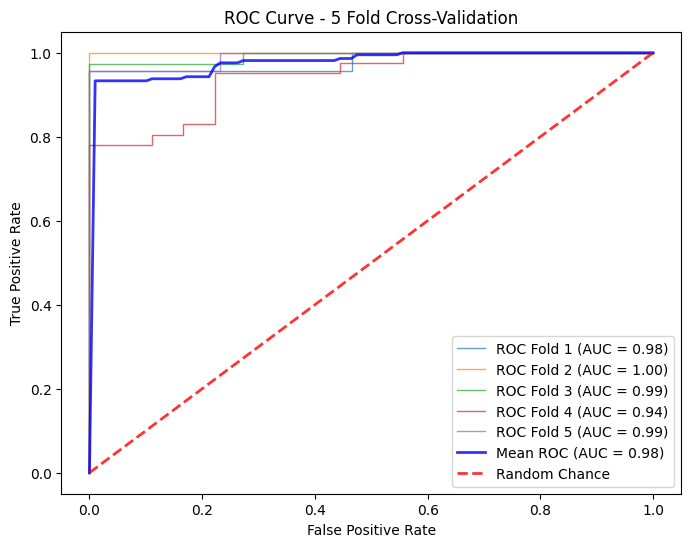

In [131]:
# Working code for plotting ROC Curve

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import KFold
import numpy as np

# Assuming you have your data and model ready
# X = x
X= pd.concat([x_train,x_test])
y= pd.concat([y_train,y_test])
# y = your_labels  # Target variable

# Initialize KFold with 5 folds
kf = KFold(n_splits=5, shuffle=True, random_state=42)

plt.figure(figsize=(8, 6))

# Initialize variables to store mean values of true positive rates (tprs) and area under curve (aucs)
mean_tpr = 0.0
mean_fpr = np.linspace(0, 1, 100)
all_tpr = []

for i, (train_index, test_index) in enumerate(kf.split(X)):
    X_train, X_test = X.iloc[train_index], X.iloc[test_index]
    Y_train, Y_test = y.iloc[train_index], y.iloc[test_index]

    # Fit your model
    model.fit(X_train, Y_train)

    # Predict probabilities for positive class
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Compute ROC curve and area under the curve
    fpr, tpr, _ = roc_curve(Y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    # Plot ROC curve for this fold
    plt.plot(fpr, tpr, lw=1, alpha=0.7,
             label=f'ROC Fold {i+1} (AUC = {roc_auc:.2f})')

    # Interpolate tpr at mean_fpr
    mean_tpr += np.interp(mean_fpr, fpr, tpr)
    mean_tpr[0] = 0.0

# Calculate mean of tprs and auc across all folds
mean_tpr /= kf.get_n_splits(X)
mean_auc = auc(mean_fpr, mean_tpr)

# Plot mean ROC curve
plt.plot(mean_fpr, mean_tpr, color='b',
         label=f'Mean ROC (AUC = {mean_auc:.2f})', lw=2, alpha=0.8)

# Plot the random chance line
plt.plot([0, 1], [0, 1], linestyle='--', lw=2, color='r',
         label='Random Chance', alpha=.8)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - 5 Fold Cross-Validation')
plt.legend(loc='lower right')
plt.show()


In [132]:
y.value_counts()

1    216
0     81
Name: Diagnosis, dtype: int64

In [ ]:
Thoda rest karlijiye warn rest in peace ho jayegene

# Dimensionlaity Reduction and Feature Selection Techniques

In [ ]:
# !pip install boruta

In [ ]:
#Applying BORUTA algorithm

# from sklearn.datasets import load_diabetes
from sklearn.ensemble import RandomForestRegressor
from boruta import BorutaPy
import pandas as pd
import numpy as np

# # let's load the load_diabetes() dataset from sklearn
# X, y = load_diabetes(return_X_y=True, as_frame=True)

# let's initialize a RF model 
model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=1)
model.fit(x,y)

# let's initialize Boruta
feat_selector = BorutaPy(
    verbose=2,
    estimator=model,
    n_estimators='auto',
    max_iter=10  # number of iterations to perform
   
)

# train Boruta
# N.B.: X and y must be numpy arrays
feat_selector.fit(np.array(x), np.array(y))

# print support and ranking for each feature
print("\n------Support and Ranking for each feature------")
for i in range(len(feat_selector.support_)):
    if feat_selector.support_[i]:
        print("Passes the test: ", X.columns[i],
              " - Ranking: ", feat_selector.ranking_[i])
    else:
        print("Doesn't pass the test: ",
              X.columns[i], " - Ranking: ", feat_selector.ranking_[i])
        
        
        
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)



sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly



brt15 = sel_col[sel_col.values<16]
brt15.index

In [ ]:
sel_col = pd.Series(feat_selector.ranking_,index=x.columns)
sel_col.sort_values(inplace=True)

In [ ]:
sel_col.plot(kind='bar',yticks=np.arange(33)) #It gives rank so aork accordingly

In [ ]:
df2.info()

In [ ]:
brt15 = sel_col[sel_col.values<16]
brt15.index

In [ ]:
# ruk jaana yaha....

## Shap Value

In [ ]:
# !pip install shap

In [ ]:
import shap
model.fit(x_train,y_train)
explainer = shap.Explainer(model.predict, x_test)
shap_values = explainer(x_test)


In [ ]:
shap.plots.bar(shap_values)

In [ ]:
shap.plots.waterfall(shap_values[0])

In [ ]:
shap.plots.beeswarm(shap_values)

In [ ]:
cols =["Appendix_Diameter","Alvarado_Score","Paedriatic_Appendicitis_Score","Thrombocyte_Count","Coughing_Pain","CRP",
       "WBC_Count","Height","Peritonitis_binary"] 
cols

In [ ]:
# error

## Information Gain

In [ ]:
from sklearn.feature_selection import mutual_info_classif
import matplotlib.pyplot as plt

importance = mutual_info_classif(x,y,random_state=0)
feat_importance = pd.Series(importance, x.columns[0:len(x.columns)])
feat_importance.plot(kind='barh',color = 'teal')

In [ ]:
mutual_info = pd.Series(importance)
mutual_info.index = x.columns
mutual_info.sort_values(ascending=False)

In [ ]:
# from sklearn.feature_selection import SelectKBest
# sel_five_cols = SelectKBest(mutual_info_classif, k=0.9)
# sel_five_cols.fit(x_train, y_train)
# x_train.columns[sel_five_cols.get_support()]

In [ ]:
cols = mutual_info[mutual_info>0].index
cols
# x = x.loc[:,cols]
# x.shape

In [ ]:
df3 = df.loc[:,cols]
df3.dropna(inplace =True)

In [ ]:
df3.shape

# Applying Fisher Score for feature selection

In [ ]:
# pip install skfeature-chappers

In [ ]:
# from skfeature.feat_selection import fisher_score
from skfeature.function.similarity_based import fisher_score
ranks = fisher_score.fisher_score(np.array(x),np.array(y))
feat_importance = pd.Series(ranks, x.columns[0:len(x.columns)])
fi = feat_importance.sort_values()
fi.plot(kind='barh',color = 'teal')
cols = ranks[ranks<25]

In [ ]:
cols

In [ ]:
x_= x.iloc[:, cols]
print("The features retained after using this techniques are :")
print(x_.columns)
df3.shape

## Variance Threshold as Feature Selection

In [ ]:
from sklearn.feature_selection import VarianceThreshold
v_threshold = VarianceThreshold(threshold=0.2)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

In [ ]:
v_threshold = VarianceThreshold(threshold=0.4)
x2 = v_threshold.fit_transform(x)
x2.shape

In [ ]:
mask = v_threshold.get_support(indices=True)
selected_cols = x.loc[:,x.columns[mask]]
selected_cols.columns

## Chi-square Test

In [ ]:
x.columns
non_cat = ["Age","BMI","Height","Weight","Appendix_Diameter","RBC_Count","Body_Temperature"]
x1 = x.drop(non_cat,axis=1)

In [ ]:
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import chi2
#Convert to catregorial data by converting data to integers
X_cat = x1.astype(int)

#three features with highest chi-squared statistics are selected
chi2_features = SelectKBest(chi2, k =15)
X_best_features = chi2_features.fit_transform(X_cat,y)

#Reduced features
print('Original feature number :',X_cat.shape[1])
print('Reduced feature number :',X_best_features.shape[1])

In [ ]:
X_best_features
selected_features = x1.columns[:][chi2_features.get_support()] 
print("\nSelected Features:") 
print(selected_features)

In [ ]:
non_cat(Index)

In [ ]:
cols = df2.columns
num_cols = df._get_numeric_data().columns
print(num_cols)
# Out[68]: Index([u'0', u'1', u'2'], dtype='object')
list(set(cols) - set(num_cols))